## Analise dos dados 

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [54]:
arquivo = "/Users/anapocai/Desktop/Estagio/Enter/Hackathon/Hackaton_Enter_Base_Candidatos.xlsx"

df_resultados = pd.read_excel(
    arquivo,
    sheet_name="Resultados dos processos"
)

df_subsidios = pd.read_excel(
    arquivo,
    sheet_name="Subsídios disponibilizados",
    header=1
)

In [55]:
print("Resultados:")
print(df_resultados.shape)
display(df_resultados.head())

print("\nSubsídios:")
print(df_subsidios.shape)
display(df_subsidios.head())

Resultados:
(60000, 8)


,Número do processo,UF,Assunto,Sub-assunto,Resultado macro,Resultado micro,Valor da causa,Valor da condenação/indenização
0,1764352-89.2025.8.06.1818,CE,Não reconhece operação,Genérico,Não Êxito,Parcial procedência,13534.00,7714.38
1,5638325-36.2025.8.17.4124,PE,Não reconhece operação,Golpe,Não Êxito,Parcial procedência,7883.63,3784.14
2,1037491-89.2025.8.18.1658,PI,Não reconhece operação,Golpe,Não Êxito,Parcial procedência,8561.97,6507.10
3,9547931-23.2025.8.04.4188,AM,Não reconhece operação,Golpe,Êxito,Improcedência,5693.13,0.00
4,9999446-69.2025.8.04.4264,AM,Não reconhece operação,Golpe,Êxito,Improcedência,8515.67,0.00



Subsídios:
(60000, 7)


,Número do processos,Contrato,Extrato,Comprovante de crédito,Dossiê,Demonstrativo de evolução da dívida,Laudo referenciado
0,1764352-89.2025.8.06.1818,0,0,0,1,1,1
1,5638325-36.2025.8.17.4124,1,1,0,1,1,1
2,1037491-89.2025.8.18.1658,0,1,1,1,1,0
3,9547931-23.2025.8.04.4188,1,1,1,1,1,0
4,9999446-69.2025.8.04.4264,0,1,0,1,1,1


In [56]:
print("RESULTADOS")
df_resultados.info()

print("\nSUBSÍDIOS")
df_subsidios.info()

RESULTADOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Número do processo               60000 non-null  object 
 1   UF                               60000 non-null  object 
 2   Assunto                          60000 non-null  object 
 3   Sub-assunto                      60000 non-null  object 
 4   Resultado macro                  60000 non-null  object 
 5   Resultado micro                  60000 non-null  object 
 6   Valor da causa                   60000 non-null  float64
 7   Valor da condenação/indenização  60000 non-null  float64
dtypes: float64(2), object(6)
memory usage: 3.7+ MB

SUBSÍDIOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------              

In [57]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets

from IPython.display import display, clear_output

In [ ]:
ufs = sorted(df_resultados["UF"].dropna().unique())

seletor_uf = widgets.Dropdown(
    options=ufs,
    value=ufs[0],
    description="UF:",
    style={"description_width": "initial"}
)

output = widgets.Output()

In [59]:
df_resultados["UF"].unique()

array(['CE', 'PE', 'PI', 'AM', 'SC', 'DF', 'BA', 'PB', 'SE', 'MA', 'AP',
       'MT', 'RN', 'MS', 'PA', 'RS', 'GO', 'RJ', 'MG', 'AL', 'RO', 'SP',
       'PR', 'AC', 'ES', 'TO'], dtype=object)

In [60]:
def analisar_uf(uf):

    df_uf = df_resultados[df_resultados["UF"] == uf]

    total_casos = len(df_uf)

    distribuicao = (
        df_uf["Resultado macro"]
        .value_counts()
        .reset_index()
    )

    distribuicao.columns = ["Resultado macro", "Quantidade"]

    taxa_nao_exito = (
        df_uf["Resultado macro"]
        .eq("Não Êxito")
        .mean()
    )

    print(f"UF selecionada: {uf}")
    print(f"Total de casos: {total_casos:,}")
    print(f"Taxa de Não Êxito: {taxa_nao_exito:.3f}")

    fig = px.pie(
        distribuicao,
        names="Resultado macro",
        values="Quantidade",
        title=f"Resultado dos processos - {uf}",
        hole=0.1
    )

    fig.update_traces(
        textposition="inside",
        textinfo="percent+label"
    )

    fig.update_layout(
        showlegend=True
    )

    fig.show()

In [61]:
def atualizar(change):

    with output:

        clear_output(wait=True)

        analisar_uf(change["new"])

seletor_uf.observe(
    atualizar,
    names="value"
)

In [62]:
display(seletor_uf, output)

with output:
    analisar_uf(seletor_uf.value)

Dropdown(description='UF:', options=('AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', '…

Output()

In [63]:
colunas_documentos = [
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

df["qtd_documentos"] = df[colunas_documentos].sum(axis=1)

df = df_resultados.merge(
    df_subsidios,
    left_on="Número do processo",
    right_on="Número do processos",
    how="left"
)

df.drop(columns="Número do processos", inplace=True)

df["qtd_documentos"] = df[colunas_documentos].sum(axis=1)

df["nao_exito"] = (
    df["Resultado macro"] == "Não Êxito"
).astype(int)

analise_documentos = (
    df.groupby("qtd_documentos")
      .agg(
          total_casos=("nao_exito", "size"),
          taxa_nao_exito=("nao_exito", "mean")
      )
      .reset_index()
)

analise_documentos

,qtd_documentos,total_casos,taxa_nao_exito
0,0,57,1.00
1,1,745,0.97
2,2,3498,0.87
3,3,8811,0.66
4,4,15719,0.36
5,5,19518,0.13
6,6,11652,0.04


In [64]:
import plotly.express as px

fig = px.bar(
    analise_documentos,
    x="qtd_documentos",
    y="taxa_nao_exito",
    text="taxa_nao_exito",
    title="Taxa de Não Êxito por quantidade de documentos",
    labels={
        "qtd_documentos": "Quantidade de documentos disponíveis",
        "taxa_nao_exito": "Taxa de Não Êxito"
    }
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_yaxes(
    range=[0, 1],
    tickformat=".0%"
)

fig.show()

In [65]:
analise_contrato = (
    df.groupby("Contrato")
      .agg(
          total_casos=("nao_exito", "size"),
          taxa_nao_exito=("nao_exito", "mean")
      )
      .reset_index()
)

analise_contrato

,Contrato,total_casos,taxa_nao_exito
0,0,17017,0.75
1,1,42983,0.13


In [66]:
for documento in colunas_documentos:

    resultado = (
        df.groupby(documento)
          .agg(
              total_casos=("nao_exito", "size"),
              taxa_nao_exito=("nao_exito", "mean")
          )
    )

    print(f"\n{documento}")
    display(resultado)


Contrato


,total_casos,taxa_nao_exito
Contrato,,
0,17017,0.75
1,42983,0.13



Extrato


,total_casos,taxa_nao_exito
Extrato,,
0,11105,0.82
1,48895,0.19



Comprovante de crédito


...

,total_casos,taxa_nao_exito
Dossiê,,
0,18014,0.30
1,41986,0.30



Demonstrativo de evolução da dívida


,total_casos,taxa_nao_exito
Demonstrativo de evolução da dívida,,
0,13785,0.39
1,46215,0.28



Laudo referenciado


,total_casos,taxa_nao_exito
Laudo referenciado,,
0,11941,0.30
1,48059,0.30


In [67]:
combinacoes = (
    df.groupby([
        "Contrato",
        "Extrato",
        "Comprovante de crédito"
    ])
    .agg(
        total_casos=("nao_exito", "size"),
        taxa_nao_exito=("nao_exito", "mean")
    )
    .reset_index()
)

combinacoes

,Contrato,Extrato,Comprovante de crédito,total_casos,taxa_nao_exito
0,0,0,0,3880,0.99
1,0,0,1,2613,0.95
2,0,1,0,5113,0.77
3,0,1,1,5411,0.47
4,1,0,0,2220,0.74
5,1,0,1,2392,0.47
6,1,1,0,12373,0.13
7,1,1,1,25998,0.04


In [105]:
colunas_documentos = [
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

df["qtd_documentos"] = df[colunas_documentos].sum(axis=1)

In [106]:
distribuicao_micro = (
    df["Resultado micro"]
    .value_counts()
    .reset_index()
)

distribuicao_micro.columns = ["Resultado micro", "Quantidade"]

distribuicao_micro["Proporção"] = (
    distribuicao_micro["Quantidade"] / len(df)
)

distribuicao_micro

,Resultado micro,Quantidade,Proporção
0,Improcedência,27935,0.47
1,Extinção,13798,0.23
2,Parcial procedência,12248,0.20
3,Procedência,5739,0.10
4,Acordo,280,0.00


In [107]:
fig = px.bar(
    distribuicao_micro,
    x="Resultado micro",
    y="Quantidade",
    text="Quantidade",
    title="Distribuição dos Resultados Micro"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

In [108]:
micro_macro = pd.crosstab(
    df["Resultado micro"],
    df["Resultado macro"],
    normalize="index"
)

micro_macro

Resultado macro,Não Êxito,Êxito
Resultado micro,,
Acordo,1.00,0.00
Extinção,0.00,1.00
Improcedência,0.00,1.00
Parcial procedência,1.00,0.00
Procedência,1.00,0.00


In [109]:
micro_uf = (
    df.groupby(["UF", "Resultado micro"])
      .size()
      .reset_index(name="Quantidade")
)

micro_uf["Proporção"] = (
    micro_uf["Quantidade"]
    / micro_uf.groupby("UF")["Quantidade"].transform("sum")
)

micro_uf.head()

,UF,Resultado micro,Quantidade,Proporção
0,AC,Acordo,11,0.00
1,AC,Extinção,550,0.24
2,AC,Improcedência,1121,0.49
3,AC,Parcial procedência,429,0.19
4,AC,Procedência,197,0.09


In [111]:
cores_micro = {
    "Improcedência": "darkgreen",         # êxito
    "Extinção": "lightgreen",             # êxito
    "Parcial procedência": "gold",        # não êxito
    "Procedência": "orangered",           # não êxito
    "Acordo": "red"                       # não êxito
}

ordem_micro = [
    "Improcedência",
    "Extinção",
    "Parcial procedência",
    "Procedência",
    "Acordo"
]

fig = px.bar(
    micro_uf,
    x="UF",
    y="Proporção",
    color="Resultado micro",
    title="Distribuição dos Resultados Micro por UF",
    barmode="stack",
    hover_data=["Quantidade"],
    color_discrete_map=cores_micro,
    category_orders={"Resultado micro": ordem_micro}
)

fig.update_yaxes(
    tickformat=".0%"
)

fig.show()

## ML 

In [69]:
df["target"] = (
    df["Resultado macro"] == "Êxito"
).astype(int)

df["target"].value_counts(normalize=True)

features = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

X = df[features]
y = df["target"]

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
target
1   0.70
0   0.30
Name: proportion, dtype: float64

Teste:
target
1   0.70
0   0.30
Name: proportion, dtype: float64


In [73]:
categoricas = [
    "UF",
    "Sub-assunto"
]

numericas = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            "num",
            StandardScaler(),
            numericas
        )
    ]
)

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [75]:
modelo_logistico.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['UF', 'Sub-assunto']),
                                                 ('num', StandardScaler(),
                                                  ['Valor da causa', 'Contrato',
                                                   'Extrato',
                                                   'Comprovante de crédito',
                                                   'Dossiê',
                                                   'Demonstrativo de evolução '
                                                   'da dívida',
                                                   'Laudo referenciado'])])),
                ('modelo', LogisticRegression(max_iter=1000))])

In [79]:
y_pred = modelo_logistico.predict(X_test)
prob_exito = modelo_logistico.predict_proba(X_test)[:, 1]
prob_nao_exito = 1 - prob_exito

In [80]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Não Êxito", "Êxito"]
    )
)

              precision    recall  f1-score   support

   Não Êxito       0.81      0.75      0.78      3653
       Êxito       0.89      0.92      0.91      8347

    accuracy                           0.87     12000
   macro avg       0.85      0.84      0.84     12000
weighted avg       0.87      0.87      0.87     12000



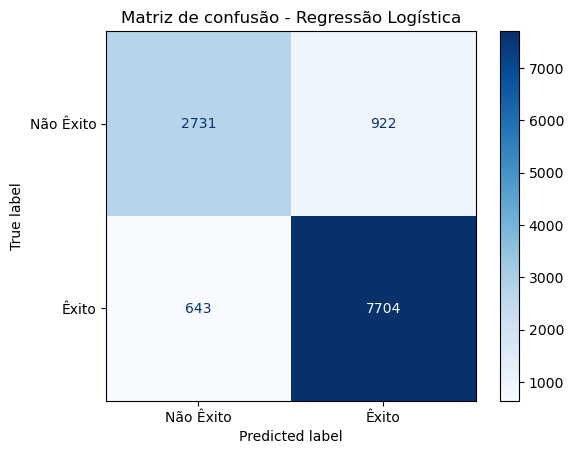

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Não Êxito", "Êxito"],
    cmap="Blues"
)

plt.title("Matriz de confusão - Regressão Logística")
plt.show()

In [82]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    prob_exito
)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.921


In [83]:
resultado_teste = X_test.copy()

resultado_teste["real"] = y_test
resultado_teste["previsto"] = y_pred
resultado_teste["prob_exito"] = prob_exito
resultado_teste["prob_nao_exito"] = prob_nao_exito

resultado_teste.head(10)

,UF,Sub-assunto,Valor da causa,Contrato,Extrato,Comprovante de crédito,Dossiê,Demonstrativo de evolução da dívida,Laudo referenciado,real,previsto,prob_exito,prob_nao_exito
52354,RN,Genérico,22628.97,1,1,0,0,1,0,1,1,0.96,0.04
33780,AL,Golpe,11595.22,0,1,1,1,0,1,1,0,0.35,0.65
21232,RO,Genérico,7414.07,1,1,1,1,0,1,1,1,0.98,0.02
28197,TO,Golpe,22516.83,1,1,1,0,1,1,1,1,0.97,0.03
15964,AC,Golpe,20659.38,0,0,0,1,0,1,0,0,0.01,0.99
24316,RN,Genérico,11843.16,1,1,1,1,1,0,1,1,0.99,0.01
18572,RO,Golpe,9175.43,1,1,0,1,1,1,1,1,0.88,0.12
26743,DF,Golpe,6913.07,1,1,1,1,1,1,1,1,0.95,0.05
47501,PE,Golpe,15394.61,1,1,1,1,1,1,1,1,0.95,0.05
32552,PB,Genérico,18062.98,1,1,1,0,0,1,1,1,0.98,0.02


In [84]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [92]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            "num",
            StandardScaler(),
            numericas
        )
    ]
)

modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [91]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            "num",
            "passthrough",
            numericas
        )
    ]
)

modelo_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_leaf=50,
                random_state=42
            )
        )
    ]
)

modelo_tree.fit(X_train, y_train)

y_pred_tree = modelo_tree.predict(X_test)

prob_tree = modelo_tree.predict_proba(X_test)[:, 1]

In [90]:
modelo_svm = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "modelo",
            LinearSVC(
                random_state=42
            )
        )
    ]
)

modelo_svm.fit(X_train, y_train)

y_pred_svm = modelo_svm.predict(X_test)

score_svm = modelo_svm.decision_function(X_test)

auc_svm = roc_auc_score(
    y_test,
    score_svm
)

print(f"ROC-AUC SVM: {auc_svm:.3f}")

ROC-AUC SVM: 0.921


In [101]:
def avaliar_modelo(nome, y_true, y_pred, scores):

    return {
        "Modelo": nome,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision Êxito": precision_score(
            y_true,
            y_pred,
            pos_label=1
        ),

        "Recall Êxito": recall_score(
            y_true,
            y_pred,
            pos_label=1
        ),

        "Recall Não Êxito": recall_score(
            y_true,
            y_pred,
            pos_label=0
        ),

        "F1": f1_score(
            y_true,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            scores
        )
    }

In [102]:
y_pred_log = modelo_logistico.predict(X_test)

prob_log = modelo_logistico.predict_proba(X_test)[:, 1]

resultados = []

resultados.append(
    avaliar_modelo(
        "Regressão Logística",
        y_test,
        y_pred_log,
        prob_log
    )
)

resultados.append(
    avaliar_modelo(
        "SVM",
        y_test,
        y_pred_svm,
        score_svm
    )
)

resultados.append(
    avaliar_modelo(
        "Decision Tree",
        y_test,
        y_pred_tree,
        prob_tree
    )
)

resultados.append(
    avaliar_modelo(
        "Random Forest",
        y_test,
        y_pred_rf,
        prob_rf
    )
)

comparacao = pd.DataFrame(resultados)

comparacao

,Modelo,Accuracy,Precision Êxito,Recall Êxito,Recall Não Êxito,F1,ROC-AUC
0,Regressão Logística,0.87,0.89,0.92,0.75,0.91,0.92
1,SVM,0.87,0.90,0.91,0.78,0.91,0.92
2,Decision Tree,0.87,0.90,0.91,0.77,0.90,0.92
3,Random Forest,0.87,0.89,0.92,0.74,0.91,0.92


In [103]:
def escolher_melhor_modelo(comparacao):

    df = comparacao.copy()

    # Pesos das métricas
    pesos = {
        "ROC-AUC": 0.30,
        "Recall Não Êxito": 0.30,
        "F1": 0.15,
        "Accuracy": 0.10,
        "Precision Êxito": 0.05,
        "Recall Êxito": 0.10
    }

    # Calcula uma pontuação final ponderada
    df["Score Final"] = sum(
        df[metrica] * peso
        for metrica, peso in pesos.items()
    )

    # Ordena do melhor para o pior
    ranking = df.sort_values(
        "Score Final",
        ascending=False
    ).reset_index(drop=True)

    melhor_modelo = ranking.iloc[0]["Modelo"]

    print(f"Melhor modelo: {melhor_modelo}")
    print(
        f"Score Final: "
        f"{ranking.iloc[0]['Score Final']:.4f}"
    )

    return ranking

In [104]:
ranking_modelos = escolher_melhor_modelo(comparacao)

ranking_modelos

Melhor modelo: SVM
Score Final: 0.8677


,Modelo,Accuracy,Precision Êxito,Recall Êxito,Recall Não Êxito,F1,ROC-AUC,Score Final
0,SVM,0.87,0.90,0.91,0.78,0.91,0.92,0.87
1,Decision Tree,0.87,0.90,0.91,0.77,0.90,0.92,0.86
2,Regressão Logística,0.87,0.89,0.92,0.75,0.91,0.92,0.86
3,Random Forest,0.87,0.89,0.92,0.74,0.91,0.92,0.86


In [112]:
target = "Resultado micro"

X = df[features]
y = df[target]

features = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

y.value_counts()

Resultado micro
Improcedência          27935
Extinção               13798
Parcial procedência    12248
Procedência             5739
Acordo                   280
Name: count, dtype: int64

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categoricas = [
    "UF",
    "Sub-assunto"
]

numericas = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            "num",
            StandardScaler(),
            numericas
        )
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        ),
        (
            "num",
            "passthrough",
            numericas
        )
    ]
)

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

modelo_logistico_multi = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

modelo_logistico_multi.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['UF', 'Sub-assunto']),
                                                 ('num', StandardScaler(),
                                                  ['Valor da causa', 'Contrato',
                                                   'Extrato',
                                                   'Comprovante de crédito',
                                                   'Dossiê',
                                                   'Demonstrativo de evolução '
                                                   'da dívida',
                                                   'Laudo referenciado'])])),
                ('modelo',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [118]:
y_pred_log_multi = modelo_logistico_multi.predict(X_test)

In [119]:
prob_log_multi = modelo_logistico_multi.predict_proba(X_test)

In [120]:
from sklearn.tree import DecisionTreeClassifier

modelo_tree_multi = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=30,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

modelo_tree_multi.fit(
    X_train,
    y_train
)

y_pred_tree_multi = modelo_tree_multi.predict(X_test)

In [121]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf_multi = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_rf_multi.fit(
    X_train,
    y_train
)

y_pred_rf_multi = modelo_rf_multi.predict(X_test)

prob_rf_multi = modelo_rf_multi.predict_proba(X_test)

In [122]:
from sklearn.svm import LinearSVC

modelo_svm_multi = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "modelo",
            LinearSVC(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

modelo_svm_multi.fit(
    X_train,
    y_train
)

y_pred_svm_multi = modelo_svm_multi.predict(X_test)

In [123]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

def avaliar_multiclasse(nome, y_true, y_pred):

    return {
        "Modelo": nome,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "F1 Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }

In [124]:
resultados_multi = []

resultados_multi.append(
    avaliar_multiclasse(
        "Regressão Logística",
        y_test,
        y_pred_log_multi
    )
)

resultados_multi.append(
    avaliar_multiclasse(
        "SVM",
        y_test,
        y_pred_svm_multi
    )
)

resultados_multi.append(
    avaliar_multiclasse(
        "Decision Tree",
        y_test,
        y_pred_tree_multi
    )
)

resultados_multi.append(
    avaliar_multiclasse(
        "Random Forest",
        y_test,
        y_pred_rf_multi
    )
)

comparacao_multi = pd.DataFrame(resultados_multi)

comparacao_multi.sort_values(
    "F1 Macro",
    ascending=False
)

,Modelo,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted
3,Random Forest,0.39,0.36,0.31,0.41
2,Decision Tree,0.36,0.33,0.28,0.38
0,Regressão Logística,0.35,0.34,0.28,0.37
1,SVM,0.57,0.34,0.28,0.46


In [125]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf_multi,
        digits=3
    )
)

                     precision    recall  f1-score   support

             Acordo      0.017     0.125     0.029        56
           Extinção      0.290     0.403     0.337      2759
      Improcedência      0.608     0.418     0.496      5587
Parcial procedência      0.432     0.234     0.303      2450
        Procedência      0.274     0.613     0.379      1148

           accuracy                          0.394     12000
          macro avg      0.324     0.359     0.309     12000
       weighted avg      0.464     0.394     0.407     12000



In [128]:
classes = modelo_rf_multi.named_steps["modelo"].classes_
classes

array(['Acordo', 'Extinção', 'Improcedência', 'Parcial procedência',
       'Procedência'], dtype=object)

In [130]:
colunas_documentos = [
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

df["qtd_documentos"] = df[colunas_documentos].sum(axis=1)

In [129]:
features = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

In [131]:
numericas = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

In [132]:
from sklearn.inspection import permutation_importance

importancia = permutation_importance(
    modelo_rf_multi,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [133]:
importancia_df = pd.DataFrame({
    "Variável": X_test.columns,
    "Importância": importancia.importances_mean,
    "Desvio": importancia.importances_std
})

importancia_df = importancia_df.sort_values(
    "Importância",
    ascending=False
)

importancia_df

,Variável,Importância,Desvio
3,Contrato,0.07,0.00
4,Extrato,0.04,0.00
5,Comprovante de crédito,0.00,0.00
1,Sub-assunto,0.00,0.00
2,Valor da causa,-0.00,0.00
0,UF,-0.00,0.00
8,Laudo referenciado,-0.00,0.00
7,Demonstrativo de evolução da dívida,-0.00,0.00
6,Dossiê,-0.00,0.00


In [134]:
fig = px.bar(
    importancia_df,
    x="Importância",
    y="Variável",
    orientation="h",
    error_x="Desvio",
    title="Importância das variáveis para prever o Resultado Micro"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    }
)

fig.show()

In [135]:
analise_qtd_docs = pd.crosstab(
    df["qtd_documentos"],
    df["Resultado micro"],
    normalize="index"
)

analise_qtd_docs

Resultado micro,Acordo,Extinção,Improcedência,Parcial procedência,Procedência
qtd_documentos,,,,,
0,0.00,0.00,0.00,0.61,0.39
1,0.01,0.01,0.02,0.65,0.31
2,0.01,0.04,0.09,0.57,0.29
3,0.01,0.11,0.23,0.45,0.20
4,0.01,0.21,0.43,0.24,0.11
5,0.00,0.29,0.58,0.09,0.04
6,0.00,0.32,0.64,0.03,0.01


In [136]:
fig = px.imshow(
    analise_qtd_docs,
    text_auto=".2f",
    aspect="auto",
    title="Resultado Micro por quantidade de documentos",
    labels={
        "x": "Resultado Micro",
        "y": "Quantidade de documentos",
        "color": "Proporção"
    }
)

fig.show()

In [137]:
documentos_micro = (
    df.groupby("Resultado micro")[colunas_documentos]
      .mean()
      .T
)

documentos_micro

Resultado micro,Acordo,Extinção,Improcedência,Parcial procedência,Procedência
Contrato,0.26,0.90,0.90,0.30,0.30
Extrato,0.50,0.95,0.95,0.51,0.50
Comprovante de crédito,0.46,0.70,0.70,0.40,0.39
Dossiê,0.71,0.70,0.70,0.70,0.70
Demonstrativo de evolução da dívida,0.73,0.80,0.80,0.71,0.69
Laudo referenciado,0.79,0.80,0.80,0.80,0.80


In [138]:
fig = px.imshow(
    documentos_micro,
    text_auto=".2f",
    aspect="auto",
    title="Presença de cada documento por Resultado Micro",
    labels={
        "x": "Resultado Micro",
        "y": "Documento",
        "color": "Proporção"
    }
)

fig.show()

In [139]:
colunas_documentos = [
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado"
]

df["qtd_documentos"] = df[colunas_documentos].sum(axis=1)

In [140]:
macro_geral = (
    df["Resultado macro"]
    .value_counts()
    .reset_index()
)

macro_geral.columns = [
    "Resultado macro",
    "Quantidade"
]

macro_geral["Proporção"] = (
    macro_geral["Quantidade"] / len(df)
)

macro_geral

,Resultado macro,Quantidade,Proporção
0,Êxito,41733,0.70
1,Não Êxito,18267,0.30


In [141]:
fig = px.bar(
    macro_geral,
    x="Resultado macro",
    y="Quantidade",
    text="Quantidade",
    color="Resultado macro",
    color_discrete_map={
        "Êxito": "green",
        "Não Êxito": "red"
    },
    title="Distribuição do Resultado Macro"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

In [142]:
macro_documentos = pd.crosstab(
    df["qtd_documentos"],
    df["Resultado macro"],
    normalize="index"
)

macro_documentos

Resultado macro,Não Êxito,Êxito
qtd_documentos,,
0,1.00,0.00
1,0.97,0.03
2,0.87,0.13
3,0.66,0.34
4,0.36,0.64
5,0.13,0.87
6,0.04,0.96


In [143]:
macro_documentos_plot = (
    macro_documentos
    .reset_index()
    .melt(
        id_vars="qtd_documentos",
        var_name="Resultado macro",
        value_name="Proporção"
    )
)

In [144]:
fig = px.bar(
    macro_documentos_plot,
    x="qtd_documentos",
    y="Proporção",
    color="Resultado macro",
    barmode="stack",
    color_discrete_map={
        "Êxito": "green",
        "Não Êxito": "red"
    },
    title="Resultado Macro por Quantidade de Documentos"
)

fig.update_yaxes(
    tickformat=".0%",
    range=[0, 1]
)

fig.update_xaxes(
    title="Quantidade de documentos disponíveis"
)

fig.show()

In [145]:
df["target_exito"] = (
    df["Resultado macro"] == "Êxito"
).astype(int)

In [146]:
exito_por_docs = (
    df.groupby("qtd_documentos")
      .agg(
          total_casos=("target_exito", "size"),
          taxa_exito=("target_exito", "mean")
      )
      .reset_index()
)

exito_por_docs

,qtd_documentos,total_casos,taxa_exito
0,0,57,0.00
1,1,745,0.03
2,2,3498,0.13
3,3,8811,0.34
4,4,15719,0.64
5,5,19518,0.87
6,6,11652,0.96


In [147]:
fig = px.bar(
    exito_por_docs,
    x="qtd_documentos",
    y="taxa_exito",
    text="taxa_exito",
    title="Taxa de Êxito por Quantidade de Documentos"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_yaxes(
    tickformat=".0%",
    range=[0, 1]
)

fig.update_xaxes(
    title="Quantidade de documentos"
)

fig.show()

In [148]:
analise_documentos_macro = []

for documento in colunas_documentos:

    temp = (
        df.groupby(documento)
          .agg(
              total=("target_exito", "size"),
              taxa_exito=("target_exito", "mean")
          )
          .reset_index()
    )

    temp["Documento"] = documento

    analise_documentos_macro.append(temp)

analise_documentos_macro = pd.concat(
    analise_documentos_macro,
    ignore_index=True
)

analise_documentos_macro

,Contrato,total,taxa_exito,Documento,Extrato,Comprovante de crédito,Dossiê,Demonstrativo de evolução da dívida,Laudo referenciado
0,0.00,17017,0.25,Contrato,NaN,NaN,NaN,NaN,NaN
1,1.00,42983,0.87,Contrato,NaN,NaN,NaN,NaN,NaN
2,NaN,11105,0.18,Extrato,0.00,NaN,NaN,NaN,NaN
3,NaN,48895,0.81,Extrato,1.00,NaN,NaN,NaN,NaN
4,NaN,23586,0.53,Comprovante de crédito,NaN,0.00,NaN,NaN,NaN
5,NaN,36414,0.80,Comprovante de crédito,NaN,1.00,NaN,NaN,NaN
6,NaN,18014,0.70,Dossiê,NaN,NaN,0.00,NaN,NaN
7,NaN,41986,0.70,Dossiê,NaN,NaN,1.00,NaN,NaN
8,NaN,13785,0.61,Demonstrativo de evolução da dívida,NaN,NaN,NaN,0.00,NaN
9,NaN,46215,0.72,Demonstrativo de evolução da dívida,NaN,NaN,NaN,1.00,NaN


In [149]:
impacto_documentos = []

for documento in colunas_documentos:

    sem_doc = df.loc[
        df[documento] == 0,
        "target_exito"
    ].mean()

    com_doc = df.loc[
        df[documento] == 1,
        "target_exito"
    ].mean()

    impacto_documentos.append({
        "Documento": documento,
        "Êxito sem documento": sem_doc,
        "Êxito com documento": com_doc,
        "Diferença": com_doc - sem_doc
    })

impacto_documentos = pd.DataFrame(
    impacto_documentos
).sort_values(
    "Diferença",
    ascending=False
)

impacto_documentos

,Documento,Êxito sem documento,Êxito com documento,Diferença
1,Extrato,0.18,0.81,0.63
0,Contrato,0.25,0.87,0.63
2,Comprovante de crédito,0.53,0.80,0.27
4,Demonstrativo de evolução da dívida,0.61,0.72,0.12
3,Dossiê,0.70,0.70,-0.00
5,Laudo referenciado,0.70,0.70,-0.00


In [150]:
impacto_plot = impacto_documentos.melt(
    id_vars="Documento",
    value_vars=[
        "Êxito sem documento",
        "Êxito com documento"
    ],
    var_name="Situação",
    value_name="Taxa de Êxito"
)

In [151]:
fig = px.bar(
    impacto_plot,
    x="Documento",
    y="Taxa de Êxito",
    color="Situação",
    barmode="group",
    title="Taxa de Êxito com e sem cada documento"
)

fig.update_yaxes(
    tickformat=".0%",
    range=[0, 1]
)

fig.update_xaxes(
    tickangle=30
)

fig.show()

In [152]:
macro_uf = (
    df.groupby(["UF", "Resultado macro"])
      .size()
      .reset_index(name="Quantidade")
)

macro_uf["Proporção"] = (
    macro_uf["Quantidade"]
    / macro_uf.groupby("UF")["Quantidade"].transform("sum")
)

In [153]:
fig = px.bar(
    macro_uf,
    x="UF",
    y="Proporção",
    color="Resultado macro",
    barmode="stack",
    color_discrete_map={
        "Êxito": "green",
        "Não Êxito": "red"
    },
    hover_data=["Quantidade"],
    title="Resultado Macro por UF"
)

fig.update_yaxes(
    tickformat=".0%"
)

fig.show()

In [154]:
macro_subassunto = pd.crosstab(
    df["Sub-assunto"],
    df["Resultado macro"],
    normalize="index"
)

macro_subassunto

Resultado macro,Não Êxito,Êxito
Sub-assunto,,
Genérico,0.17,0.83
Golpe,0.36,0.64


In [157]:
features_macro = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

X_macro = df[features_macro]

y_macro = (
    df["Resultado macro"] == "Êxito"
).astype(int)

In [158]:
from sklearn.model_selection import train_test_split

X_train_macro, X_test_macro, y_train_macro, y_test_macro = train_test_split(
    X_macro,
    y_macro,
    test_size=0.2,
    random_state=42,
    stratify=y_macro
)

In [159]:
categoricas_macro = [
    "UF",
    "Sub-assunto"
]

numericas_macro = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

In [160]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_macro = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas_macro
        ),
        (
            "num",
            "passthrough",
            numericas_macro
        )
    ]
)

In [161]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

modelo_rf_macro = Pipeline(
    steps=[
        ("preprocessor", preprocessor_macro),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_rf_macro.fit(
    X_train_macro,
    y_train_macro
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['UF', 'Sub-assunto']),
                                                 ('num', 'passthrough',
                                                  ['Valor da causa', 'Contrato',
                                                   'Extrato',
                                                   'Comprovante de crédito',
                                                   'Dossiê',
                                                   'Demonstrativo de evolução '
                                                   'da dívida',
                                                   'Laudo referenciado',
                                                   'qtd_documentos'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=20,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [162]:
from sklearn.inspection import permutation_importance

importancia_macro = permutation_importance(
    modelo_rf_macro,
    X_test_macro,
    y_test_macro,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [163]:
importancia_macro_df = pd.DataFrame({
    "Variável": X_test_macro.columns,
    "Importância": importancia_macro.importances_mean,
    "Desvio": importancia_macro.importances_std
}).sort_values(
    "Importância",
    ascending=False
)

importancia_macro_df

,Variável,Importância,Desvio
3,Contrato,0.10,0.00
4,Extrato,0.06,0.00
9,qtd_documentos,0.02,0.00
1,Sub-assunto,0.01,0.00
5,Comprovante de crédito,0.01,0.00
0,UF,0.00,0.00
6,Dossiê,0.00,0.00
8,Laudo referenciado,0.00,0.00
7,Demonstrativo de evolução da dívida,0.00,0.00
2,Valor da causa,-0.00,0.00


In [164]:
fig = px.bar(
    importancia_macro_df,
    x="Importância",
    y="Variável",
    orientation="h",
    error_x="Desvio",
    title="Importância das variáveis para prever Êxito"
)

fig.update_layout(
    yaxis={
        "categoryorder": "total ascending"
    }
)

fig.show()

In [165]:
df_score = df[
    df["Resultado macro"] == "Não Êxito"
].copy()

In [166]:
mapa_score = {
    "Acordo": 0.0,
    "Parcial procedência": 0.5,
    "Procedência": 1.0
}

df_score["score_desfecho"] = (
    df_score["Resultado micro"]
    .map(mapa_score)
)

In [167]:
df_score[
    ["Resultado micro", "score_desfecho"]
].value_counts()

Resultado micro      score_desfecho
Parcial procedência  0.50              12248
Procedência          1.00               5739
Acordo               0.00                280
Name: count, dtype: int64

In [168]:
df_score["score_desfecho"].value_counts(normalize=True)

score_desfecho
0.50   0.67
1.00   0.31
0.00   0.02
Name: proportion, dtype: float64

In [169]:
features_score = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

X_score = df_score[features_score]
y_score = df_score["score_desfecho"]

In [170]:
from sklearn.model_selection import train_test_split

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score,
    y_score,
    test_size=0.2,
    random_state=42,
    stratify=y_score
)

In [171]:
print("Treino:")
print(y_train_score.value_counts(normalize=True))

print("\nTeste:")
print(y_test_score.value_counts(normalize=True))

Treino:
score_desfecho
0.50   0.67
1.00   0.31
0.00   0.02
Name: proportion, dtype: float64

Teste:
score_desfecho
0.50   0.67
1.00   0.31
0.00   0.02
Name: proportion, dtype: float64


In [172]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [173]:
categoricas_score = [
    "UF",
    "Sub-assunto"
]

numericas_score = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

In [174]:
preprocessor_scaled_score = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categoricas_score
        ),
        (
            "num",
            StandardScaler(),
            numericas_score
        )
    ]
)

In [175]:
preprocessor_tree_score = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categoricas_score
        ),
        (
            "num",
            "passthrough",
            numericas_score
        )
    ]
)

In [176]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

modelo_ridge = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled_score),
        (
            "modelo",
            Ridge(alpha=1.0)
        )
    ]
)

modelo_ridge.fit(
    X_train_score,
    y_train_score
)

pred_ridge = modelo_ridge.predict(X_test_score)

In [177]:
from sklearn.svm import SVR

modelo_svr = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled_score),
        (
            "modelo",
            SVR(
                kernel="rbf",
                C=1.0,
                epsilon=0.1
            )
        )
    ]
)

modelo_svr.fit(
    X_train_score,
    y_train_score
)

pred_svr = modelo_svr.predict(X_test_score)

In [181]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf_score = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_score),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

modelo_rf_score.fit(
    X_train_score,
    y_train_score
)

pred_rf = modelo_rf_score.predict(X_test_score)

In [178]:
from sklearn.tree import DecisionTreeRegressor

modelo_tree_score = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_score),
        (
            "modelo",
            DecisionTreeRegressor(
                max_depth=8,
                min_samples_leaf=30,
                random_state=42
            )
        )
    ]
)

modelo_tree_score.fit(
    X_train_score,
    y_train_score
)

pred_tree = modelo_tree_score.predict(X_test_score)

In [179]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_score),
        (
            "modelo",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

modelo_gb.fit(
    X_train_score,
    y_train_score
)

pred_gb = modelo_gb.predict(X_test_score)

In [182]:
import numpy as np

pred_ridge = np.clip(pred_ridge, 0, 1)
pred_svr   = np.clip(pred_svr, 0, 1)
pred_tree  = np.clip(pred_tree, 0, 1)
pred_rf    = np.clip(pred_rf, 0, 1)
pred_gb    = np.clip(pred_gb, 0, 1)

In [183]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [184]:
def avaliar_regressao(nome, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "Modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

In [185]:
resultados_score = []

resultados_score.append(
    avaliar_regressao(
        "Ridge",
        y_test_score,
        pred_ridge
    )
)

resultados_score.append(
    avaliar_regressao(
        "SVR",
        y_test_score,
        pred_svr
    )
)

resultados_score.append(
    avaliar_regressao(
        "Decision Tree",
        y_test_score,
        pred_tree
    )
)

resultados_score.append(
    avaliar_regressao(
        "Random Forest",
        y_test_score,
        pred_rf
    )
)

resultados_score.append(
    avaliar_regressao(
        "Gradient Boosting",
        y_test_score,
        pred_gb
    )
)

comparacao_score = pd.DataFrame(
    resultados_score
)

comparacao_score.sort_values("MAE")

,Modelo,MAE,RMSE,R²
1,SVR,0.21,0.25,-0.04
2,Decision Tree,0.22,0.25,-0.00
4,Gradient Boosting,0.22,0.24,0.02
3,Random Forest,0.22,0.24,0.01
0,Ridge,0.22,0.24,0.02


In [186]:
resultado_score = X_test_score.copy()

resultado_score["Resultado real"] = (
    df_score.loc[
        X_test_score.index,
        "Resultado micro"
    ]
)

resultado_score["Score real"] = y_test_score

resultado_score["Score previsto"] = pred_rf

resultado_score[
    [
        "Resultado real",
        "Score real",
        "Score previsto",
        "qtd_documentos",
        "Contrato",
        "Extrato",
        "Valor da causa"
    ]
].head(20)

,Resultado real,Score real,Score previsto,qtd_documentos,Contrato,Extrato,Valor da causa
38755,Parcial procedência,0.50,0.67,4,0,0,21701.46
28019,Parcial procedência,0.50,0.65,5,1,1,10766.18
23568,Procedência,1.00,0.67,3,1,1,4774.52
18995,Procedência,1.00,0.67,2,0,0,15575.73
18207,Parcial procedência,0.50,0.65,4,0,0,16168.07
19019,Procedência,1.00,0.67,2,0,0,13851.15
23702,Parcial procedência,0.50,0.61,5,0,1,14344.86
18078,Parcial procedência,0.50,0.68,5,1,1,24549.68
20114,Parcial procedência,0.50,0.67,2,0,0,18201.29
52940,Parcial procedência,0.50,0.67,3,0,0,11555.09


In [192]:
def converter_para_classe(pred):
    pred = np.asarray(pred)

    return np.where(
        pred < 0.25,
        0.0,
        np.where(
            pred < 0.75,
            0.5,
            1.0
        )
    )


def converter_labels(y):
    return (np.asarray(y) * 2).astype(int)


y_test_classes = converter_labels(y_test_score)

In [193]:
classe_ridge_int = converter_labels(classe_ridge)
classe_svr_int   = converter_labels(classe_svr)
classe_tree_int  = converter_labels(classe_tree)
classe_rf_int    = converter_labels(classe_rf)
classe_gb_int    = converter_labels(classe_gb)

In [194]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef
)

def avaliar_classificacao_score(nome, y_true, y_pred):

    return {
        "Modelo": nome,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "F1 Weighted": f1_score(
            y_true,
            y_pred,
            average="weighted"
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        )
    }

In [195]:
resultados_classificacao = []

resultados_classificacao.append(
    avaliar_classificacao_score(
        "Ridge",
        y_test_classes,
        classe_ridge_int
    )
)

resultados_classificacao.append(
    avaliar_classificacao_score(
        "SVR",
        y_test_classes,
        classe_svr_int
    )
)

resultados_classificacao.append(
    avaliar_classificacao_score(
        "Decision Tree",
        y_test_classes,
        classe_tree_int
    )
)

resultados_classificacao.append(
    avaliar_classificacao_score(
        "Random Forest",
        y_test_classes,
        classe_rf_int
    )
)

resultados_classificacao.append(
    avaliar_classificacao_score(
        "Gradient Boosting",
        y_test_classes,
        classe_gb_int
    )
)

comparacao_classificacao = pd.DataFrame(
    resultados_classificacao
)

comparacao_classificacao.sort_values(
    "MCC",
    ascending=False
)

,Modelo,Accuracy,F1 Macro,F1 Weighted,MCC
3,Random Forest,0.67,0.28,0.55,0.05
4,Gradient Boosting,0.67,0.27,0.54,0.04
2,Decision Tree,0.67,0.28,0.55,0.03
1,SVR,0.66,0.28,0.55,0.01
0,Ridge,0.67,0.27,0.54,0.00


In [196]:
def escolher_melhor_modelo(comparacao):

    df = comparacao.copy()

    pesos = {
        "MCC": 0.40,
        "F1 Macro": 0.30,
        "F1 Weighted": 0.20,
        "Accuracy": 0.10
    }

    df["Score Final"] = sum(
        df[metrica] * peso
        for metrica, peso in pesos.items()
    )

    ranking = df.sort_values(
        "Score Final",
        ascending=False
    ).reset_index(drop=True)

    melhor = ranking.iloc[0]

    print(f"Melhor modelo: {melhor['Modelo']}")
    print(f"Score Final: {melhor['Score Final']:.4f}")
    print(f"MCC: {melhor['MCC']:.4f}")
    print(f"F1 Macro: {melhor['F1 Macro']:.4f}")
    print(f"Accuracy: {melhor['Accuracy']:.4f}")

    return ranking

In [197]:
ranking_modelos = escolher_melhor_modelo(
    comparacao_classificacao
)

ranking_modelos

Melhor modelo: Random Forest
Score Final: 0.2819
MCC: 0.0538
F1 Macro: 0.2783
Accuracy: 0.6721


,Modelo,Accuracy,F1 Macro,F1 Weighted,MCC,Score Final
0,Random Forest,0.67,0.28,0.55,0.05,0.28
1,Gradient Boosting,0.67,0.27,0.54,0.04,0.27
2,Decision Tree,0.67,0.28,0.55,0.03,0.27
3,SVR,0.66,0.28,0.55,0.01,0.26
4,Ridge,0.67,0.27,0.54,0.00,0.25


In [203]:
import numpy as np

df_score = df[
    df["Resultado macro"] == "Não Êxito"
].copy()

df_score["proporcao_condenacao"] = (
    df_score["Valor da condenação/indenização"]
    / df_score["Valor da causa"]
)

df_score["proporcao_condenacao"] = (
    df_score["proporcao_condenacao"]
    .clip(0, 1)
)

df_score["score_desfecho"] = np.select(
    [
        df_score["Resultado micro"] == "Acordo",
        df_score["Resultado micro"] == "Parcial procedência",
        df_score["Resultado micro"] == "Procedência"
    ],
    [
        0,
        df_score["proporcao_condenacao"],
        1
    ],
    default=np.nan
)

df_score[
    [
        "Resultado micro",
        "Valor da causa",
        "Valor da condenação/indenização",
        "proporcao_condenacao",
        "score_desfecho"
    ]
].head(20)

,Resultado micro,Valor da causa,Valor da condenação/indenização,proporcao_condenacao,score_desfecho
0,Parcial procedência,13534.00,7714.38,0.57,0.57
1,Parcial procedência,7883.63,3784.14,0.48,0.48
2,Parcial procedência,8561.97,6507.10,0.76,0.76
5,Parcial procedência,16961.06,12720.80,0.75,0.75
6,Procedência,11180.00,11180.00,1.00,1.00
8,Parcial procedência,16021.50,9773.11,0.61,0.61
12,Procedência,18988.78,17089.90,0.90,1.00
22,Parcial procedência,22052.77,11246.91,0.51,0.51
25,Procedência,19419.34,16700.63,0.86,1.00
26,Procedência,13427.87,11413.69,0.85,1.00


In [204]:
df_score.groupby("Resultado micro")["score_desfecho"].agg(
    quantidade="count",
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max"
)

,quantidade,media,mediana,minimo,maximo
Resultado micro,,,,,
Acordo,280,0.00,0.00,0.00,0.00
Parcial procedência,12248,0.62,0.63,0.20,1.00
Procedência,5739,1.00,1.00,1.00,1.00


In [205]:
df_pp = df_score[
    df_score["Resultado micro"] == "Parcial procedência"
]

df_pp["score_desfecho"].describe()

count   12248.00
mean        0.62
std         0.17
min         0.20
25%         0.49
50%         0.63
75%         0.75
max         1.00
Name: score_desfecho, dtype: float64

In [206]:
import plotly.express as px

fig = px.histogram(
    df_pp,
    x="score_desfecho",
    nbins=20,
    title="Distribuição do score - Parcial procedência"
)

fig.update_xaxes(
    title="Condenação / Valor da causa",
    range=[0, 1]
)

fig.update_yaxes(
    title="Número de processos"
)

fig.show()

In [207]:
import numpy as np
import pandas as pd

features_score = [
    "UF",
    "Sub-assunto",
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

df_modelo = df_score[
    features_score + ["score_desfecho"]
].copy()

# Segurança contra NaN / infinito
df_modelo = df_modelo.replace([np.inf, -np.inf], np.nan)
df_modelo = df_modelo.dropna()

X_score = df_modelo[features_score]
y_score = df_modelo["score_desfecho"]

print(X_score.shape)
print(y_score.describe())

(18267, 10)
count   18267.00
mean        0.73
std         0.24
min         0.00
25%         0.55
50%         0.74
75%         1.00
max         1.00
Name: score_desfecho, dtype: float64


In [208]:
from sklearn.model_selection import train_test_split

X_train_score, X_test_score, y_train_score, y_test_score = train_test_split(
    X_score,
    y_score,
    test_size=0.20,
    random_state=42
)

print("Treino:", X_train_score.shape)
print("Teste:", X_test_score.shape)

Treino: (14613, 10)
Teste: (3654, 10)


In [209]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categoricas_score = [
    "UF",
    "Sub-assunto"
]

numericas_score = [
    "Valor da causa",
    "Contrato",
    "Extrato",
    "Comprovante de crédito",
    "Dossiê",
    "Demonstrativo de evolução da dívida",
    "Laudo referenciado",
    "qtd_documentos"
]

In [210]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categoricas_score
        ),
        (
            "num",
            StandardScaler(),
            numericas_score
        )
    ]
)

In [211]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categoricas_score
        ),
        (
            "num",
            "passthrough",
            numericas_score
        )
    ]
)

In [212]:
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.neural_network import MLPRegressor

In [213]:
modelos = {

    "Dummy": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", DummyRegressor(strategy="mean"))
    ]),

    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", Lasso(alpha=0.001))
    ]),

    "Elastic Net": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", ElasticNet(
            alpha=0.001,
            l1_ratio=0.5
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", KNeighborsRegressor(
            n_neighbors=20,
            weights="distance"
        ))
    ]),

    "SVR": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", SVR(
            kernel="rbf",
            C=1.0,
            epsilon=0.05
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=20,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=200,
            max_depth=8,
            random_state=42
        ))
    ]),

    "AdaBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("modelo", AdaBoostRegressor(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]),

    "MLP": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("modelo", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ])
}

In [214]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

resultados = []
modelos_treinados = {}
previsoes = {}

for nome, modelo in modelos.items():

    inicio = time.time()

    # Treina
    modelo.fit(
        X_train_score,
        y_train_score
    )

    # Prevê
    pred = modelo.predict(X_test_score)

    # O score só pode estar entre 0 e 1
    pred = np.clip(pred, 0, 1)

    tempo = time.time() - inicio

    # Métricas
    mae = mean_absolute_error(
        y_test_score,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_score,
            pred
        )
    )

    r2 = r2_score(
        y_test_score,
        pred
    )

    resultados.append({
        "Modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Tempo (s)": tempo
    })

    modelos_treinados[nome] = modelo
    previsoes[nome] = pred

    print(
        f"{nome}: "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R²={r2:.4f}"
    )

Dummy: MAE=0.2038 | RMSE=0.2395 | R²=-0.0000
Linear Regression: MAE=0.1917 | RMSE=0.2294 | R²=0.0831
Ridge: MAE=0.1917 | RMSE=0.2294 | R²=0.0831
Lasso: MAE=0.1926 | RMSE=0.2295 | R²=0.0817
Elastic Net: MAE=0.1920 | RMSE=0.2293 | R²=0.0837
KNN: MAE=0.2076 | RMSE=0.2527 | R²=-0.1129
SVR: MAE=0.2005 | RMSE=0.2440 | R²=-0.0375
Decision Tree: MAE=0.1936 | RMSE=0.2322 | R²=0.0604
Random Forest: MAE=0.1936 | RMSE=0.2319 | R²=0.0625
Extra Trees: MAE=0.1944 | RMSE=0.2328 | R²=0.0550
Gradient Boosting: MAE=0.1922 | RMSE=0.2297 | R²=0.0807
Hist Gradient Boosting: MAE=0.1925 | RMSE=0.2301 | R²=0.0773
AdaBoost: MAE=0.2003 | RMSE=0.2362 | R²=0.0279
MLP: MAE=0.1949 | RMSE=0.2342 | R²=0.0437


In [215]:
comparacao_score = pd.DataFrame(resultados)

ranking_score = (
    comparacao_score
    .sort_values(
        ["MAE", "RMSE"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

ranking_score

,Modelo,MAE,RMSE,R²,Tempo (s)
0,Linear Regression,0.19,0.23,0.08,0.02
1,Ridge,0.19,0.23,0.08,0.01
2,Elastic Net,0.19,0.23,0.08,0.78
3,Gradient Boosting,0.19,0.23,0.08,2.03
4,Hist Gradient Boosting,0.19,0.23,0.08,0.81
5,Lasso,0.19,0.23,0.08,0.02
6,Random Forest,0.19,0.23,0.06,1.31
7,Decision Tree,0.19,0.23,0.06,0.03
8,Extra Trees,0.19,0.23,0.06,1.06
9,MLP,0.19,0.23,0.04,0.80


In [216]:
melhor_nome = ranking_score.iloc[0]["Modelo"]

melhor_modelo = modelos_treinados[melhor_nome]

print("Melhor modelo:")
print(melhor_nome)

print(
    f"MAE: "
    f"{ranking_score.iloc[0]['MAE']:.4f}"
)

print(
    f"RMSE: "
    f"{ranking_score.iloc[0]['RMSE']:.4f}"
)

print(
    f"R²: "
    f"{ranking_score.iloc[0]['R²']:.4f}"
)

Melhor modelo:
Linear Regression
MAE: 0.1917
RMSE: 0.2294
R²: 0.0831


In [217]:
pred_melhor = previsoes[melhor_nome]

resultado_melhor = pd.DataFrame({
    "Score real": y_test_score.values,
    "Score previsto": pred_melhor
})

resultado_melhor.head(20)

,Score real,Score previsto
0,0.63,0.72
1,0.59,0.71
2,1.00,0.73
3,1.00,0.72
4,0.83,0.73
5,1.00,0.76
6,0.50,0.72
7,0.73,0.73
8,0.72,0.71
9,1.00,0.73


In [218]:
fig = px.scatter(
    resultado_melhor,
    x="Score real",
    y="Score previsto",
    opacity=0.4,
    title=f"Score real vs previsto - {melhor_nome}"
)

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=1,
    y1=1,
    line=dict(
        dash="dash"
    )
)

fig.update_xaxes(range=[0, 1])
fig.update_yaxes(range=[0, 1])

fig.show()

In [228]:
DESCONTO_ACORDO = 0.20

resultado_melhor["Score previsto ajustado"] = np.clip(
    resultado_melhor["Score previsto"] * (1 - DESCONTO_ACORDO),
    0,
    1
)

In [229]:
fig = px.scatter(
    resultado_melhor,
    x="Score real",
    y="Score previsto ajustado",
    opacity=0.4,
    title=f"Score real vs previsto ajustado - {melhor_nome}"
)

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=1,
    y1=1,
    line=dict(
        dash="dash"
    )
)

fig.update_xaxes(
    range=[0, 1],
    title="Score real"
)

fig.update_yaxes(
    range=[0, 1],
    title="Score previsto com desconto de 20%"
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# ============================================================
# CONFIGURAÇÃO
# ============================================================
#
# Queremos que o acordo represente pelo menos
# 10% de economia em relação ao valor histórico esperado.
#
# Exemplo:
#
# Real esperado = 1.00
#
# Previsto ajustado deve ser no máximo:
#
# 1.00 * 0.90 = 0.90
#
# ============================================================

ECONOMIA_MINIMA = 0.10


# ============================================================
# 1. PREPARAR OS DADOS
# ============================================================

analise_desconto = resultado_melhor.copy()


analise_desconto = analise_desconto.dropna(
    subset=[
        "Score real",
        "Score previsto"
    ]
)


analise_desconto["Score real"] = (
    analise_desconto["Score real"]
    .clip(0, 1)
)


analise_desconto["Score previsto"] = (
    analise_desconto["Score previsto"]
    .clip(0, 1)
)


# ============================================================
# 2. TOTAL REAL
# ============================================================

total_real = (
    analise_desconto[
        "Score real"
    ].sum()
)


# ============================================================
# 3. LIMITE DE PAGAMENTO
# ============================================================
#
# Para garantir pelo menos 10% de economia:
#
# Total previsto ajustado
# <=
# 90% do total real
#
# ============================================================

limite_total = (
    total_real
    * (1 - ECONOMIA_MINIMA)
)


# ============================================================
# 4. TESTAR DESCONTOS
# ============================================================
#
# Testando descontos:
#
# 0%
# 0.5%
# 1%
# ...
# 50%
#
# ============================================================

descontos = np.arange(
    0,
    0.501,
    0.005
)


resultados_desconto = []


for desconto in descontos:


    # --------------------------------------------------------
    # SCORE COM DESCONTO
    # --------------------------------------------------------

    score_ajustado = (
        analise_desconto[
            "Score previsto"
        ]
        * (1 - desconto)
    )


    score_ajustado = np.clip(
        score_ajustado,
        0,
        1
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(

        analise_desconto[
            "Score real"
        ],

        score_ajustado
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(

        mean_squared_error(

            analise_desconto[
                "Score real"
            ],

            score_ajustado
        )
    )


    # --------------------------------------------------------
    # TOTAL PREVISTO COM DESCONTO
    # --------------------------------------------------------

    total_previsto = (
        score_ajustado.sum()
    )


    # --------------------------------------------------------
    # ECONOMIA AGREGADA
    # --------------------------------------------------------
    #
    # Exemplo:
    #
    # previsto / real = 0.85
    #
    # economia = 15%
    #
    # --------------------------------------------------------

    economia = (
        1
        -
        (
            total_previsto
            /
            total_real
        )
    )


    # --------------------------------------------------------
    # % DOS CASOS EM QUE PAGAMOS MENOS
    # OU IGUAL AO HISTÓRICO
    # --------------------------------------------------------

    percentual_abaixo_real = (

        (
            score_ajustado
            <=
            analise_desconto[
                "Score real"
            ]
        )

        .mean()
    )


    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    resultados_desconto.append({

        "Desconto":
            desconto,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "Total previsto":
            total_previsto,

        "Total real":
            total_real,

        "Razão previsto/real":
            (
                total_previsto
                /
                total_real
            ),

        "Economia":
            economia,

        "% casos abaixo do real":
            percentual_abaixo_real
    })


# ============================================================
# 5. DATAFRAME DOS DESCONTOS
# ============================================================

df_descontos = pd.DataFrame(
    resultados_desconto
)


# ============================================================
# 6. FILTRAR DESCONTOS VIÁVEIS
# ============================================================
#
# Para ser economicamente viável:
#
# Total previsto
# <=
# 90% do Total real
#
# Isso garante pelo menos 10% de economia.
#
# ============================================================

opcoes_viaveis = df_descontos[

    df_descontos[
        "Total previsto"
    ]

    <= limite_total

].copy()


# ============================================================
# 7. ESCOLHER O MELHOR DESCONTO
# ============================================================
#
# Entre os descontos que garantem pelo menos
# 10% de economia, escolher aquele com menor MAE.
#
# ============================================================

if len(opcoes_viaveis) > 0:


    melhor = (

        opcoes_viaveis

        .sort_values(
            "MAE"
        )

        .iloc[0]

    )


else:


    print(
        "\nATENÇÃO:"
        "\nNenhum desconto entre 0% e 50% "
        "conseguiu atingir a economia mínima de 10%."
    )


    melhor = (

        df_descontos

        .sort_values(
            "Economia",
            ascending=False
        )

        .iloc[0]

    )


DESCONTO_OTIMO = (
    melhor[
        "Desconto"
    ]
)


# ============================================================
# 8. APLICAR O DESCONTO ESCOLHIDO
# ============================================================

analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto"
    ]

    * (
        1
        -
        DESCONTO_OTIMO
    )

)


analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto ajustado"
    ]

    .clip(
        0,
        1
    )

)


# ============================================================
# 9. MÉTRICAS ANTES E DEPOIS
# ============================================================

mae_original = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto"
    ]
)


mae_ajustado = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto ajustado"
    ]
)


rmse_original = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto"
        ]
    )
)


rmse_ajustado = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto ajustado"
        ]
    )
)


# ============================================================
# 10. TOTAIS
# ============================================================

total_original = (

    analise_desconto[
        "Score previsto"
    ].sum()

)


total_ajustado = (

    analise_desconto[
        "Score previsto ajustado"
    ].sum()

)


# ============================================================
# 11. ECONOMIA FINAL
# ============================================================

economia_final = (

    1
    -
    (
        total_ajustado
        /
        total_real
    )

)


# ============================================================
# 12. CASOS ABAIXO DO REAL
# ============================================================

percentual_abaixo = (

    (
        analise_desconto[
            "Score previsto ajustado"
        ]

        <=

        analise_desconto[
            "Score real"
        ]
    )

    .mean()
)


# ============================================================
# 13. MOSTRAR RESULTADOS
# ============================================================

print(
    "\n=========================================="
)

print(
    "ANÁLISE DA POLÍTICA DE ACORDO"
)

print(
    "=========================================="
)


print(
    f"\nEconomia mínima exigida: "
    f"{ECONOMIA_MINIMA:.1%}"
)


print(
    f"Desconto selecionado: "
    f"{DESCONTO_OTIMO:.1%}"
)


print(
    f"\nMAE original: "
    f"{mae_original:.4f}"
)

print(
    f"MAE ajustado: "
    f"{mae_ajustado:.4f}"
)


print(
    f"\nRMSE original: "
    f"{rmse_original:.4f}"
)

print(
    f"RMSE ajustado: "
    f"{rmse_ajustado:.4f}"
)


print(
    f"\nTotal score real: "
    f"{total_real:.2f}"
)


print(
    f"Total previsto original: "
    f"{total_original:.2f}"
)


print(
    f"Total previsto ajustado: "
    f"{total_ajustado:.2f}"
)


print(
    f"\nLimite para garantir "
    f"{ECONOMIA_MINIMA:.0%} de economia: "
    f"{limite_total:.2f}"
)


print(
    f"\nEconomia agregada obtida: "
    f"{economia_final:.1%}"
)


print(
    f"Previsto ajustado / Real: "
    f"{total_ajustado / total_real:.3f}"
)


print(
    f"\nCasos em que o previsto ajustado "
    f"é <= ao real: "
    f"{percentual_abaixo:.1%}"
)


# ============================================================
# 14. GRÁFICO
# ============================================================

fig = go.Figure()


# ------------------------------------------------------------
# PREVISÃO ORIGINAL
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto"
        ],

        mode="markers",

        name="Previsão original",

        opacity=0.20

    )

)


# ------------------------------------------------------------
# PREVISÃO AJUSTADA
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto ajustado"
        ],

        mode="markers",

        name=(
            f"Previsão ajustada "
            f"(-{DESCONTO_OTIMO:.1%})"
        ),

        opacity=0.45

    )

)


# ------------------------------------------------------------
# LINHA IDEAL
#
# y = x
# ------------------------------------------------------------

fig.add_shape(

    type="line",

    x0=0,
    y0=0,

    x1=1,
    y1=1,

    line=dict(
        dash="dash"
    )

)


# ------------------------------------------------------------
# LINHA DE 10% DE ECONOMIA
#
# y = 0.90 * x
#
# Essa linha representa:
#
# pagar 10% menos que o valor real.
#
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=[
            0,
            1
        ],

        y=[
            0,
            1 - ECONOMIA_MINIMA
        ],

        mode="lines",

        name=(
            f"Meta de economia "
            f"({ECONOMIA_MINIMA:.0%})"
        ),

        line=dict(
            dash="dot"
        )

    )

)


# ============================================================
# 15. CONFIGURAÇÕES DO GRÁFICO
# ============================================================

fig.update_layout(

    title=(

        "Score real vs previsto "
        f"— desconto selecionado: "
        f"{DESCONTO_OTIMO:.1%}"
        f" | economia obtida: "
        f"{economia_final:.1%}"

    ),

    xaxis_title=(
        "Score real"
    ),

    yaxis_title=(
        "Score previsto"
    ),

    legend_title=(
        "Comparação"
    )

)


fig.update_xaxes(
    range=[
        0,
        1
    ]
)


fig.update_yaxes(
    range=[
        0,
        1
    ]
)


fig.show()

ANÁLISE DO DESCONTO

Desconto escolhido: 0.0%

MAE original: 0.1917
MAE ajustado: 0.1917

Total score real: 2671.53
Total previsto original: 2666.75
Total previsto ajustado: 2666.75

Previsto ajustado / Real: 0.998
Casos em que o previsto ajustado é <= ao real: 50.7%


In [219]:
def score_para_classe(score):

    score = np.asarray(score)

    return np.where(
        score < 0.33,
        0,                  # baixo
        np.where(
            score < 0.66,
            1,              # médio
            2               # alto
        )
    )

In [220]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [221]:
import time

resultados = []
modelos_treinados = {}
previsoes = {}

# Classes reais
y_test_classes = score_para_classe(y_test_score)

for nome, modelo in modelos.items():

    inicio = time.time()

    # =============================
    # TREINAMENTO
    # =============================

    modelo.fit(
        X_train_score,
        y_train_score
    )

    # =============================
    # PREVISÃO CONTÍNUA
    # =============================

    pred = modelo.predict(X_test_score)

    # Score limitado entre 0 e 1
    pred = np.clip(pred, 0, 1)

    tempo = time.time() - inicio

    # =============================
    # MÉTRICAS DE REGRESSÃO
    # =============================

    mae = mean_absolute_error(
        y_test_score,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_score,
            pred
        )
    )

    r2 = r2_score(
        y_test_score,
        pred
    )

    # =============================
    # CONVERTER PARA CLASSES
    # =============================

    pred_classes = score_para_classe(pred)

    # =============================
    # MÉTRICAS DE CLASSIFICAÇÃO
    # =============================

    accuracy = accuracy_score(
        y_test_classes,
        pred_classes
    )

    recall_macro = recall_score(
        y_test_classes,
        pred_classes,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_test_classes,
        pred_classes,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_test_classes,
        pred_classes,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test_classes,
        pred_classes
    )

    # =============================
    # SALVAR
    # =============================

    resultados.append({

        "Modelo": nome,

        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,

        "Accuracy": accuracy,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "MCC": mcc,

        "Tempo (s)": tempo
    })

    modelos_treinados[nome] = modelo
    previsoes[nome] = pred

    print(
        f"{nome} | "
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R²={r2:.4f} | "
        f"Accuracy={accuracy:.4f} | "
        f"Recall={recall_macro:.4f} | "
        f"F1={f1_macro:.4f} | "
        f"MCC={mcc:.4f}"
    )

Dummy | MAE=0.2038 | RMSE=0.2395 | R²=-0.0000 | Accuracy=0.6138 | Recall=0.3333 | F1=0.2536 | MCC=0.0000
Linear Regression | MAE=0.1917 | RMSE=0.2294 | R²=0.0831 | Accuracy=0.6204 | Recall=0.3743 | F1=0.3617 | MCC=0.1473
Ridge | MAE=0.1917 | RMSE=0.2294 | R²=0.0831 | Accuracy=0.6204 | Recall=0.3743 | F1=0.3617 | MCC=0.1473
Lasso | MAE=0.1926 | RMSE=0.2295 | R²=0.0817 | Accuracy=0.6322 | Recall=0.3724 | F1=0.3520 | MCC=0.1576
Elastic Net | MAE=0.1920 | RMSE=0.2293 | R²=0.0837 | Accuracy=0.6240 | Recall=0.3728 | F1=0.3574 | MCC=0.1473
KNN | MAE=0.2076 | RMSE=0.2527 | R²=-0.1129 | Accuracy=0.5873 | Recall=0.3572 | F1=0.3480 | MCC=0.0745
SVR | MAE=0.2005 | RMSE=0.2440 | R²=-0.0375 | Accuracy=0.5947 | Recall=0.3685 | F1=0.3610 | MCC=0.1125
Decision Tree | MAE=0.1936 | RMSE=0.2322 | R²=0.0604 | Accuracy=0.6215 | Recall=0.3724 | F1=0.3580 | MCC=0.1429
Random Forest | MAE=0.1936 | RMSE=0.2319 | R²=0.0625 | Accuracy=0.6171 | Recall=0.3627 | F1=0.3416 | MCC=0.1184
Extra Trees | MAE=0.1944 | RMSE

In [222]:
comparacao_score = pd.DataFrame(resultados)

comparacao_score

,Modelo,MAE,RMSE,R²,Accuracy,Recall Macro,F1 Macro,F1 Weighted,MCC,Tempo (s)
0,Dummy,0.20,0.24,-0.00,0.61,0.33,0.25,0.47,0.00,0.02
1,Linear Regression,0.19,0.23,0.08,0.62,0.37,0.36,0.58,0.15,0.03
2,Ridge,0.19,0.23,0.08,0.62,0.37,0.36,0.58,0.15,0.02
3,Lasso,0.19,0.23,0.08,0.63,0.37,0.35,0.57,0.16,0.03
4,Elastic Net,0.19,0.23,0.08,0.62,0.37,0.36,0.58,0.15,0.76
5,KNN,0.21,0.25,-0.11,0.59,0.36,0.35,0.55,0.07,0.07
6,SVR,0.20,0.24,-0.04,0.59,0.37,0.36,0.57,0.11,8.72
7,Decision Tree,0.19,0.23,0.06,0.62,0.37,0.36,0.57,0.14,0.03
8,Random Forest,0.19,0.23,0.06,0.62,0.36,0.34,0.56,0.12,1.29
9,Extra Trees,0.19,0.23,0.06,0.62,0.37,0.35,0.56,0.13,0.92


In [231]:
def calcular_score_final(comparacao):

    df_rank = comparacao.copy()

    # =============================
    # TRANSFORMAR "MENOR É MELHOR"
    # EM "MAIOR É MELHOR"
    # =============================

    df_rank["Score MAE"] = 1 - df_rank["MAE"]
    df_rank["Score RMSE"] = 1 - df_rank["RMSE"]

    # MCC varia de -1 a 1
    # vamos transformar para 0 a 1
    df_rank["Score MCC"] = (
        df_rank["MCC"] + 1
    ) / 2

    # R² pode ser negativo
    # para o ranking limitamos entre 0 e 1
    df_rank["Score R²"] = (
        df_rank["R²"]
        .clip(lower=0, upper=1)
    )

    # =============================
    # SCORE FINAL
    # =============================

    df_rank["Score Final"] = (

        # Qualidade do score contínuo
        0.25 * df_rank["Score MAE"] +

        0.10 * df_rank["Score RMSE"] +

        0.10 * df_rank["Score R²"] +

        # Qualidade das faixas
        0.20 * df_rank["F1 Macro"] +

        0.15 * df_rank["Score MCC"] +

        0.10 * df_rank["Recall Macro"] +

        0.05 * df_rank["F1 Weighted"] +

        0.05 * df_rank["Accuracy"]
    )

    df_rank = df_rank.sort_values(
        "Score Final",
        ascending=False
    ).reset_index(drop=True)

    return df_rank

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# ============================================================
# CONFIGURAÇÃO
# ============================================================
#
# Queremos que o acordo represente pelo menos
# 10% de economia em relação ao valor histórico esperado.
#
# Exemplo:
#
# Real esperado = 1.00
#
# Previsto ajustado deve ser no máximo:
#
# 1.00 * 0.90 = 0.90
#
# ============================================================

ECONOMIA_MINIMA = 0.10


# ============================================================
# 1. PREPARAR OS DADOS
# ============================================================

analise_desconto = resultado_melhor.copy()


analise_desconto = analise_desconto.dropna(
    subset=[
        "Score real",
        "Score previsto"
    ]
)


analise_desconto["Score real"] = (
    analise_desconto["Score real"]
    .clip(0, 1)
)


analise_desconto["Score previsto"] = (
    analise_desconto["Score previsto"]
    .clip(0, 1)
)


# ============================================================
# 2. TOTAL REAL
# ============================================================

total_real = (
    analise_desconto[
        "Score real"
    ].sum()
)


# ============================================================
# 3. LIMITE DE PAGAMENTO
# ============================================================
#
# Para garantir pelo menos 10% de economia:
#
# Total previsto ajustado
# <=
# 90% do total real
#
# ============================================================

limite_total = (
    total_real
    * (1 - ECONOMIA_MINIMA)
)


# ============================================================
# 4. TESTAR DESCONTOS
# ============================================================
#
# Testando descontos:
#
# 0%
# 0.5%
# 1%
# ...
# 50%
#
# ============================================================

descontos = np.arange(
    0,
    0.501,
    0.005
)


resultados_desconto = []


for desconto in descontos:


    # --------------------------------------------------------
    # SCORE COM DESCONTO
    # --------------------------------------------------------

    score_ajustado = (
        analise_desconto[
            "Score previsto"
        ]
        * (1 - desconto)
    )


    score_ajustado = np.clip(
        score_ajustado,
        0,
        1
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(

        analise_desconto[
            "Score real"
        ],

        score_ajustado
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(

        mean_squared_error(

            analise_desconto[
                "Score real"
            ],

            score_ajustado
        )
    )


    # --------------------------------------------------------
    # TOTAL PREVISTO COM DESCONTO
    # --------------------------------------------------------

    total_previsto = (
        score_ajustado.sum()
    )


    # --------------------------------------------------------
    # ECONOMIA AGREGADA
    # --------------------------------------------------------
    #
    # Exemplo:
    #
    # previsto / real = 0.85
    #
    # economia = 15%
    #
    # --------------------------------------------------------

    economia = (
        1
        -
        (
            total_previsto
            /
            total_real
        )
    )


    # --------------------------------------------------------
    # % DOS CASOS EM QUE PAGAMOS MENOS
    # OU IGUAL AO HISTÓRICO
    # --------------------------------------------------------

    percentual_abaixo_real = (

        (
            score_ajustado
            <=
            analise_desconto[
                "Score real"
            ]
        )

        .mean()
    )


    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    resultados_desconto.append({

        "Desconto":
            desconto,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "Total previsto":
            total_previsto,

        "Total real":
            total_real,

        "Razão previsto/real":
            (
                total_previsto
                /
                total_real
            ),

        "Economia":
            economia,

        "% casos abaixo do real":
            percentual_abaixo_real
    })


# ============================================================
# 5. DATAFRAME DOS DESCONTOS
# ============================================================

df_descontos = pd.DataFrame(
    resultados_desconto
)


# ============================================================
# 6. FILTRAR DESCONTOS VIÁVEIS
# ============================================================
#
# Para ser economicamente viável:
#
# Total previsto
# <=
# 90% do Total real
#
# Isso garante pelo menos 10% de economia.
#
# ============================================================

opcoes_viaveis = df_descontos[

    df_descontos[
        "Total previsto"
    ]

    <= limite_total

].copy()


# ============================================================
# 7. ESCOLHER O MELHOR DESCONTO
# ============================================================
#
# Entre os descontos que garantem pelo menos
# 10% de economia, escolher aquele com menor MAE.
#
# ============================================================

if len(opcoes_viaveis) > 0:


    melhor = (

        opcoes_viaveis

        .sort_values(
            "MAE"
        )

        .iloc[0]

    )


else:


    print(
        "\nATENÇÃO:"
        "\nNenhum desconto entre 0% e 50% "
        "conseguiu atingir a economia mínima de 10%."
    )


    melhor = (

        df_descontos

        .sort_values(
            "Economia",
            ascending=False
        )

        .iloc[0]

    )


DESCONTO_OTIMO = (
    melhor[
        "Desconto"
    ]
)


# ============================================================
# 8. APLICAR O DESCONTO ESCOLHIDO
# ============================================================

analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto"
    ]

    * (
        1
        -
        DESCONTO_OTIMO
    )

)


analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto ajustado"
    ]

    .clip(
        0,
        1
    )

)


# ============================================================
# 9. MÉTRICAS ANTES E DEPOIS
# ============================================================

mae_original = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto"
    ]
)


mae_ajustado = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto ajustado"
    ]
)


rmse_original = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto"
        ]
    )
)


rmse_ajustado = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto ajustado"
        ]
    )
)


# ============================================================
# 10. TOTAIS
# ============================================================

total_original = (

    analise_desconto[
        "Score previsto"
    ].sum()

)


total_ajustado = (

    analise_desconto[
        "Score previsto ajustado"
    ].sum()

)


# ============================================================
# 11. ECONOMIA FINAL
# ============================================================

economia_final = (

    1
    -
    (
        total_ajustado
        /
        total_real
    )

)


# ============================================================
# 12. CASOS ABAIXO DO REAL
# ============================================================

percentual_abaixo = (

    (
        analise_desconto[
            "Score previsto ajustado"
        ]

        <=

        analise_desconto[
            "Score real"
        ]
    )

    .mean()
)


# ============================================================
# 13. MOSTRAR RESULTADOS
# ============================================================

print(
    "\n=========================================="
)

print(
    "ANÁLISE DA POLÍTICA DE ACORDO"
)

print(
    "=========================================="
)


print(
    f"\nEconomia mínima exigida: "
    f"{ECONOMIA_MINIMA:.1%}"
)


print(
    f"Desconto selecionado: "
    f"{DESCONTO_OTIMO:.1%}"
)


print(
    f"\nMAE original: "
    f"{mae_original:.4f}"
)

print(
    f"MAE ajustado: "
    f"{mae_ajustado:.4f}"
)


print(
    f"\nRMSE original: "
    f"{rmse_original:.4f}"
)

print(
    f"RMSE ajustado: "
    f"{rmse_ajustado:.4f}"
)


print(
    f"\nTotal score real: "
    f"{total_real:.2f}"
)


print(
    f"Total previsto original: "
    f"{total_original:.2f}"
)


print(
    f"Total previsto ajustado: "
    f"{total_ajustado:.2f}"
)


print(
    f"\nLimite para garantir "
    f"{ECONOMIA_MINIMA:.0%} de economia: "
    f"{limite_total:.2f}"
)


print(
    f"\nEconomia agregada obtida: "
    f"{economia_final:.1%}"
)


print(
    f"Previsto ajustado / Real: "
    f"{total_ajustado / total_real:.3f}"
)


print(
    f"\nCasos em que o previsto ajustado "
    f"é <= ao real: "
    f"{percentual_abaixo:.1%}"
)


# ============================================================
# 14. GRÁFICO
# ============================================================

fig = go.Figure()


# ------------------------------------------------------------
# PREVISÃO ORIGINAL
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto"
        ],

        mode="markers",

        name="Previsão original",

        opacity=0.20

    )

)


# ------------------------------------------------------------
# PREVISÃO AJUSTADA
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto ajustado"
        ],

        mode="markers",

        name=(
            f"Previsão ajustada "
            f"(-{DESCONTO_OTIMO:.1%})"
        ),

        opacity=0.45

    )

)


# ------------------------------------------------------------
# LINHA IDEAL
#
# y = x
# ------------------------------------------------------------

fig.add_shape(

    type="line",

    x0=0,
    y0=0,

    x1=1,
    y1=1,

    line=dict(
        dash="dash"
    )

)


# ------------------------------------------------------------
# LINHA DE 10% DE ECONOMIA
#
# y = 0.90 * x
#
# Essa linha representa:
#
# pagar 10% menos que o valor real.
#
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=[
            0,
            1
        ],

        y=[
            0,
            1 - ECONOMIA_MINIMA
        ],

        mode="lines",

        name=(
            f"Meta de economia "
            f"({ECONOMIA_MINIMA:.0%})"
        ),

        line=dict(
            dash="dot"
        )

    )

)


# ============================================================
# 15. CONFIGURAÇÕES DO GRÁFICO
# ============================================================

fig.update_layout(

    title=(

        "Score real vs previsto "
        f"— desconto selecionado: "
        f"{DESCONTO_OTIMO:.1%}"
        f" | economia obtida: "
        f"{economia_final:.1%}"

    ),

    xaxis_title=(
        "Score real"
    ),

    yaxis_title=(
        "Score previsto"
    ),

    legend_title=(
        "Comparação"
    )

)


fig.update_xaxes(
    range=[
        0,
        1
    ]
)


fig.update_yaxes(
    range=[
        0,
        1
    ]
)


fig.show()

,Modelo,MAE,RMSE,R²,Accuracy,Recall Macro,F1 Macro,MCC,Score Final
0,Ridge,0.19,0.23,0.08,0.62,0.37,0.36,0.15,0.54
1,Linear Regression,0.19,0.23,0.08,0.62,0.37,0.36,0.15,0.54
2,Elastic Net,0.19,0.23,0.08,0.62,0.37,0.36,0.15,0.54
3,Gradient Boosting,0.19,0.23,0.08,0.62,0.37,0.36,0.15,0.54
4,Lasso,0.19,0.23,0.08,0.63,0.37,0.35,0.16,0.54
5,Decision Tree,0.19,0.23,0.06,0.62,0.37,0.36,0.14,0.54
6,MLP,0.19,0.23,0.04,0.61,0.37,0.36,0.13,0.54
7,Extra Trees,0.19,0.23,0.06,0.62,0.37,0.35,0.13,0.53
8,AdaBoost,0.20,0.24,0.03,0.62,0.37,0.35,0.14,0.53
9,Random Forest,0.19,0.23,0.06,0.62,0.36,0.34,0.12,0.53


In [225]:
melhor_nome = ranking_final.iloc[0]["Modelo"]

melhor_modelo = modelos_treinados[
    melhor_nome
]

print("=" * 40)
print("MELHOR MODELO")
print("=" * 40)

print(
    f"Modelo: {melhor_nome}"
)

print(
    f"Score Final: "
    f"{ranking_final.iloc[0]['Score Final']:.4f}"
)

print(
    f"MAE: "
    f"{ranking_final.iloc[0]['MAE']:.4f}"
)

print(
    f"RMSE: "
    f"{ranking_final.iloc[0]['RMSE']:.4f}"
)

print(
    f"R²: "
    f"{ranking_final.iloc[0]['R²']:.4f}"
)

print(
    f"Accuracy: "
    f"{ranking_final.iloc[0]['Accuracy']:.4f}"
)

print(
    f"Recall Macro: "
    f"{ranking_final.iloc[0]['Recall Macro']:.4f}"
)

print(
    f"F1 Macro: "
    f"{ranking_final.iloc[0]['F1 Macro']:.4f}"
)

print(
    f"MCC: "
    f"{ranking_final.iloc[0]['MCC']:.4f}"
)

MELHOR MODELO
Modelo: Ridge
Score Final: 0.5432
MAE: 0.1917
RMSE: 0.2294
R²: 0.0831
Accuracy: 0.6204
Recall Macro: 0.3743
F1 Macro: 0.3617
MCC: 0.1473


In [226]:
feature_names = (
    modelo_ridge
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coeficientes = (
    modelo_ridge
    .named_steps["modelo"]
    .coef_
)

In [227]:
import pandas as pd

importancia_ridge = pd.DataFrame({
    "Variável": feature_names,
    "Coeficiente": coeficientes
})

importancia_ridge = importancia_ridge.sort_values(
    "Coeficiente",
    ascending=False
)

importancia_ridge

,Variável,Coeficiente
3,cat__UF_AP,0.04
27,cat__Sub-assunto_Golpe,0.04
7,cat__UF_ES,0.02
10,cat__UF_MG,0.02
2,cat__UF_AM,0.01
6,cat__UF_DF,0.01
1,cat__UF_AL,0.01
24,cat__UF_SP,0.01
19,cat__UF_RN,0.01
22,cat__UF_SC,0.01


In [232]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


# ============================================================
# CONFIGURAÇÃO
# ============================================================
#
# Queremos que o acordo represente pelo menos
# 10% de economia em relação ao valor histórico esperado.
#
# Exemplo:
#
# Real esperado = 1.00
#
# Previsto ajustado deve ser no máximo:
#
# 1.00 * 0.90 = 0.90
#
# ============================================================

ECONOMIA_MINIMA = 0.10


# ============================================================
# 1. PREPARAR OS DADOS
# ============================================================

analise_desconto = resultado_melhor.copy()


analise_desconto = analise_desconto.dropna(
    subset=[
        "Score real",
        "Score previsto"
    ]
)


analise_desconto["Score real"] = (
    analise_desconto["Score real"]
    .clip(0, 1)
)


analise_desconto["Score previsto"] = (
    analise_desconto["Score previsto"]
    .clip(0, 1)
)


# ============================================================
# 2. TOTAL REAL
# ============================================================

total_real = (
    analise_desconto[
        "Score real"
    ].sum()
)


# ============================================================
# 3. LIMITE DE PAGAMENTO
# ============================================================
#
# Para garantir pelo menos 10% de economia:
#
# Total previsto ajustado
# <=
# 90% do total real
#
# ============================================================

limite_total = (
    total_real
    * (1 - ECONOMIA_MINIMA)
)


# ============================================================
# 4. TESTAR DESCONTOS
# ============================================================
#
# Testando descontos:
#
# 0%
# 0.5%
# 1%
# ...
# 50%
#
# ============================================================

descontos = np.arange(
    0,
    0.501,
    0.005
)


resultados_desconto = []


for desconto in descontos:


    # --------------------------------------------------------
    # SCORE COM DESCONTO
    # --------------------------------------------------------

    score_ajustado = (
        analise_desconto[
            "Score previsto"
        ]
        * (1 - desconto)
    )


    score_ajustado = np.clip(
        score_ajustado,
        0,
        1
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = mean_absolute_error(

        analise_desconto[
            "Score real"
        ],

        score_ajustado
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(

        mean_squared_error(

            analise_desconto[
                "Score real"
            ],

            score_ajustado
        )
    )


    # --------------------------------------------------------
    # TOTAL PREVISTO COM DESCONTO
    # --------------------------------------------------------

    total_previsto = (
        score_ajustado.sum()
    )


    # --------------------------------------------------------
    # ECONOMIA AGREGADA
    # --------------------------------------------------------
    #
    # Exemplo:
    #
    # previsto / real = 0.85
    #
    # economia = 15%
    #
    # --------------------------------------------------------

    economia = (
        1
        -
        (
            total_previsto
            /
            total_real
        )
    )


    # --------------------------------------------------------
    # % DOS CASOS EM QUE PAGAMOS MENOS
    # OU IGUAL AO HISTÓRICO
    # --------------------------------------------------------

    percentual_abaixo_real = (

        (
            score_ajustado
            <=
            analise_desconto[
                "Score real"
            ]
        )

        .mean()
    )


    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    resultados_desconto.append({

        "Desconto":
            desconto,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "Total previsto":
            total_previsto,

        "Total real":
            total_real,

        "Razão previsto/real":
            (
                total_previsto
                /
                total_real
            ),

        "Economia":
            economia,

        "% casos abaixo do real":
            percentual_abaixo_real
    })


# ============================================================
# 5. DATAFRAME DOS DESCONTOS
# ============================================================

df_descontos = pd.DataFrame(
    resultados_desconto
)


# ============================================================
# 6. FILTRAR DESCONTOS VIÁVEIS
# ============================================================
#
# Para ser economicamente viável:
#
# Total previsto
# <=
# 90% do Total real
#
# Isso garante pelo menos 10% de economia.
#
# ============================================================

opcoes_viaveis = df_descontos[

    df_descontos[
        "Total previsto"
    ]

    <= limite_total

].copy()


# ============================================================
# 7. ESCOLHER O MELHOR DESCONTO
# ============================================================
#
# Entre os descontos que garantem pelo menos
# 10% de economia, escolher aquele com menor MAE.
#
# ============================================================

if len(opcoes_viaveis) > 0:


    melhor = (

        opcoes_viaveis

        .sort_values(
            "MAE"
        )

        .iloc[0]

    )


else:


    print(
        "\nATENÇÃO:"
        "\nNenhum desconto entre 0% e 50% "
        "conseguiu atingir a economia mínima de 10%."
    )


    melhor = (

        df_descontos

        .sort_values(
            "Economia",
            ascending=False
        )

        .iloc[0]

    )


DESCONTO_OTIMO = (
    melhor[
        "Desconto"
    ]
)


# ============================================================
# 8. APLICAR O DESCONTO ESCOLHIDO
# ============================================================

analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto"
    ]

    * (
        1
        -
        DESCONTO_OTIMO
    )

)


analise_desconto[
    "Score previsto ajustado"
] = (

    analise_desconto[
        "Score previsto ajustado"
    ]

    .clip(
        0,
        1
    )

)


# ============================================================
# 9. MÉTRICAS ANTES E DEPOIS
# ============================================================

mae_original = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto"
    ]
)


mae_ajustado = mean_absolute_error(

    analise_desconto[
        "Score real"
    ],

    analise_desconto[
        "Score previsto ajustado"
    ]
)


rmse_original = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto"
        ]
    )
)


rmse_ajustado = np.sqrt(

    mean_squared_error(

        analise_desconto[
            "Score real"
        ],

        analise_desconto[
            "Score previsto ajustado"
        ]
    )
)


# ============================================================
# 10. TOTAIS
# ============================================================

total_original = (

    analise_desconto[
        "Score previsto"
    ].sum()

)


total_ajustado = (

    analise_desconto[
        "Score previsto ajustado"
    ].sum()

)


# ============================================================
# 11. ECONOMIA FINAL
# ============================================================

economia_final = (

    1
    -
    (
        total_ajustado
        /
        total_real
    )

)


# ============================================================
# 12. CASOS ABAIXO DO REAL
# ============================================================

percentual_abaixo = (

    (
        analise_desconto[
            "Score previsto ajustado"
        ]

        <=

        analise_desconto[
            "Score real"
        ]
    )

    .mean()
)


# ============================================================
# 13. MOSTRAR RESULTADOS
# ============================================================

print(
    "\n=========================================="
)

print(
    "ANÁLISE DA POLÍTICA DE ACORDO"
)

print(
    "=========================================="
)


print(
    f"\nEconomia mínima exigida: "
    f"{ECONOMIA_MINIMA:.1%}"
)


print(
    f"Desconto selecionado: "
    f"{DESCONTO_OTIMO:.1%}"
)


print(
    f"\nMAE original: "
    f"{mae_original:.4f}"
)

print(
    f"MAE ajustado: "
    f"{mae_ajustado:.4f}"
)


print(
    f"\nRMSE original: "
    f"{rmse_original:.4f}"
)

print(
    f"RMSE ajustado: "
    f"{rmse_ajustado:.4f}"
)


print(
    f"\nTotal score real: "
    f"{total_real:.2f}"
)


print(
    f"Total previsto original: "
    f"{total_original:.2f}"
)


print(
    f"Total previsto ajustado: "
    f"{total_ajustado:.2f}"
)


print(
    f"\nLimite para garantir "
    f"{ECONOMIA_MINIMA:.0%} de economia: "
    f"{limite_total:.2f}"
)


print(
    f"\nEconomia agregada obtida: "
    f"{economia_final:.1%}"
)


print(
    f"Previsto ajustado / Real: "
    f"{total_ajustado / total_real:.3f}"
)


print(
    f"\nCasos em que o previsto ajustado "
    f"é <= ao real: "
    f"{percentual_abaixo:.1%}"
)


# ============================================================
# 14. GRÁFICO
# ============================================================

fig = go.Figure()


# ------------------------------------------------------------
# PREVISÃO ORIGINAL
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto"
        ],

        mode="markers",

        name="Previsão original",

        opacity=0.20

    )

)


# ------------------------------------------------------------
# PREVISÃO AJUSTADA
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=analise_desconto[
            "Score real"
        ],

        y=analise_desconto[
            "Score previsto ajustado"
        ],

        mode="markers",

        name=(
            f"Previsão ajustada "
            f"(-{DESCONTO_OTIMO:.1%})"
        ),

        opacity=0.45

    )

)


# ------------------------------------------------------------
# LINHA IDEAL
#
# y = x
# ------------------------------------------------------------

fig.add_shape(

    type="line",

    x0=0,
    y0=0,

    x1=1,
    y1=1,

    line=dict(
        dash="dash"
    )

)


# ------------------------------------------------------------
# LINHA DE 10% DE ECONOMIA
#
# y = 0.90 * x
#
# Essa linha representa:
#
# pagar 10% menos que o valor real.
#
# ------------------------------------------------------------

fig.add_trace(

    go.Scatter(

        x=[
            0,
            1
        ],

        y=[
            0,
            1 - ECONOMIA_MINIMA
        ],

        mode="lines",

        name=(
            f"Meta de economia "
            f"({ECONOMIA_MINIMA:.0%})"
        ),

        line=dict(
            dash="dot"
        )

    )

)


# ============================================================
# 15. CONFIGURAÇÕES DO GRÁFICO
# ============================================================

fig.update_layout(

    title=(

        "Score real vs previsto "
        f"— desconto selecionado: "
        f"{DESCONTO_OTIMO:.1%}"
        f" | economia obtida: "
        f"{economia_final:.1%}"

    ),

    xaxis_title=(
        "Score real"
    ),

    yaxis_title=(
        "Score previsto"
    ),

    legend_title=(
        "Comparação"
    )

)


fig.update_xaxes(
    range=[
        0,
        1
    ]
)


fig.update_yaxes(
    range=[
        0,
        1
    ]
)


fig.show()


ANÁLISE DA POLÍTICA DE ACORDO

Economia mínima exigida: 10.0%
Desconto selecionado: 10.0%

MAE original: 0.1917
MAE ajustado: 0.2003

RMSE original: 0.2294
RMSE ajustado: 0.2412

Total score real: 2671.53
Total previsto original: 2666.75
Total previsto ajustado: 2400.07

Limite para garantir 10% de economia: 2404.38

Economia agregada obtida: 10.2%
Previsto ajustado / Real: 0.898

Casos em que o previsto ajustado é <= ao real: 60.4%


In [235]:
import numpy as np
import pandas as pd
import plotly.express as px

resultado_melhor["Valor da causa"] = (
    X_test_score["Valor da causa"].values
)
# ============================================================
# 1. PREPARAR BASE
# ============================================================

analise_valor = resultado_melhor.copy()

analise_valor = analise_valor.dropna(
    subset=[
        "Score real",
        "Score previsto",
        "Valor da causa"
    ]
)


# ============================================================
# 2. TRANSFORMAR SCORE EM VALOR FINANCEIRO
# ============================================================

analise_valor["Valor real"] = (
    analise_valor["Score real"]
    *
    analise_valor["Valor da causa"]
)


analise_valor["Valor previsto"] = (
    analise_valor["Score previsto"]
    *
    analise_valor["Valor da causa"]
)


# ============================================================
# 3. CRIAR FAIXAS DE VALOR DA CAUSA
# ============================================================

bins = [
    0,
    2000,
    5000,
    10000,
    20000,
    50000,
    np.inf
]


labels = [
    "Até 2 mil",
    "2 a 5 mil",
    "5 a 10 mil",
    "10 a 20 mil",
    "20 a 50 mil",
    "Acima de 50 mil"
]


analise_valor["Faixa"] = pd.cut(
    analise_valor["Valor da causa"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# ============================================================
# 4. ANALISAR ERRO FINANCEIRO POR FAIXA
# ============================================================

analise_valor["Erro financeiro"] = (
    analise_valor["Valor previsto"]
    -
    analise_valor["Valor real"]
)


resumo_faixas = (
    analise_valor
    .groupby(
        "Faixa",
        observed=False
    )
    .agg(
        Casos=(
            "Valor da causa",
            "size"
        ),

        Valor_medio_causa=(
            "Valor da causa",
            "mean"
        ),

        Total_real=(
            "Valor real",
            "sum"
        ),

        Total_previsto=(
            "Valor previsto",
            "sum"
        ),

        Erro_medio_RS=(
            "Erro financeiro",
            "mean"
        )
    )
    .reset_index()
)


# ============================================================
# 5. CALCULAR QUANTO O MODELO SUPERESTIMA
# ============================================================

resumo_faixas["Razao_previsto_real"] = (
    resumo_faixas["Total_previsto"]
    /
    resumo_faixas["Total_real"]
)


resumo_faixas["Superestimacao"] = (
    resumo_faixas["Razao_previsto_real"]
    -
    1
)


print(
    resumo_faixas
)

             Faixa  Casos  Valor_medio_causa  Total_real  Total_previsto  \
0        Até 2 mil      7            1169.56     6872.14         5599.11   
1        2 a 5 mil     55            3904.75   146773.22       151971.98   
2       5 a 10 mil    541            7998.00  3161828.26      3138556.40   
3      10 a 20 mil   2480           15010.57 27225112.34     27209041.58   
4      20 a 50 mil    571           22402.11  9375950.64      9380446.96   
5  Acima de 50 mil      0                NaN        0.00            0.00   

   Erro_medio_RS  Razao_previsto_real  Superestimacao  
0        -181.86                 0.81           -0.19  
1          94.52                 1.04            0.04  
2         -43.02                 0.99           -0.01  
3          -6.48                 1.00           -0.00  
4           7.87                 1.00            0.00  
5            NaN                  NaN             NaN  


In [247]:
# ============================================================
# 6. META DE ECONOMIA POR FAIXA
# ============================================================

meta_economia = {
    "Até 2 mil": 0.00,
    "2 a 5 mil": 0.05,
    "5 a 10 mil": 0.10,
    "10 a 20 mil": 0.15,
    "20 a 50 mil": 0.20,
    "Acima de 50 mil": 0.25
}


resumo_faixas["Meta economia"] = (

    resumo_faixas[
        "Faixa"
    ]
    .astype(str)
    .map(meta_economia)

)


# ============================================================
# 7. DESCONTO NECESSÁRIO
# ============================================================

resumo_faixas["Desconto necessário"] = (

    1

    -

    (

        resumo_faixas["Total_real"]

        *

        (
            1
            -
            resumo_faixas["Meta economia"]
        )

        /

        resumo_faixas["Total_previsto"]

    )

)


# Se o modelo já prevê abaixo da meta,
# não precisamos dar desconto negativo.

resumo_faixas[
    "Desconto necessário"
] = (

    resumo_faixas[
        "Desconto necessário"
    ]
    .clip(
        lower=0,
        upper=0.50
    )

)

In [249]:
resumo_faixas[
    [
        "Faixa",
        "Casos",
        "Valor_medio_causa",
        "Total_real",
        "Total_previsto",
        "Superestimacao",
        "Meta economia",
        "Desconto necessário"
    ]
]

,Faixa,Casos,Valor_medio_causa,Total_real,Total_previsto,Superestimacao,Meta economia,Desconto necessário
0,Até 2 mil,7,1169.56,6872.14,5599.11,-0.19,0.00,0.00
1,2 a 5 mil,55,3904.75,146773.22,151971.98,0.04,0.05,0.08
2,5 a 10 mil,541,7998.00,3161828.26,3138556.40,-0.01,0.10,0.09
3,10 a 20 mil,2480,15010.57,27225112.34,27209041.58,-0.00,0.15,0.15
4,20 a 50 mil,571,22402.11,9375950.64,9380446.96,0.00,0.20,0.20
5,Acima de 50 mil,0,NaN,0.00,0.00,NaN,0.25,NaN


In [250]:
fig = px.bar(
    resumo_faixas,
    x="Faixa",
    y="Desconto necessário",
    text_auto=".1%",
    title="Desconto recomendado por faixa de valor da causa"
)

fig.update_yaxes(
    tickformat=".0%",
    title="Desconto recomendado"
)

fig.update_xaxes(
    title="Valor da causa"
)

fig.show()

In [251]:
resumo_faixas["Total após política"] = (
    resumo_faixas["Total_previsto"]
    *
    (
        1
        -
        resumo_faixas["Desconto necessário"]
    )
)

In [252]:
fig = px.bar(

    resumo_faixas,

    x="Faixa",

    y=[
        "Total_real",
        "Total_previsto",
        "Total após política"
    ],

    barmode="group",

    title=(
        "Valor real vs previsto vs ajustado "
        "por faixa de valor da causa"
    )

)

fig.update_xaxes(
    title="Valor da causa"
)

fig.update_yaxes(
    title="Valor total"
)

fig.show()

In [253]:
# ============================================================
# 1. LEVAR O DESCONTO DE CADA FAIXA PARA CADA PROCESSO
# ============================================================

mapa_desconto = (
    resumo_faixas
    .set_index("Faixa")["Desconto necessário"]
    .to_dict()
)

analise_valor["Desconto"] = (
    analise_valor["Faixa"]
    .map(mapa_desconto)
    .astype(float)
)

analise_valor["Valor ajustado"] = (
    analise_valor["Valor previsto"]
    *
    (1 - analise_valor["Desconto"])
)

In [254]:
# ============================================================
# 2. MÉDIA E DESVIO PADRÃO POR FAIXA
# ============================================================

estatisticas_faixas = (
    analise_valor
    .groupby(
        "Faixa",
        observed=False
    )
    .agg(
        Media_real=("Valor real", "mean"),
        DP_real=("Valor real", "std"),

        Media_previsto=("Valor previsto", "mean"),
        DP_previsto=("Valor previsto", "std"),

        Media_ajustado=("Valor ajustado", "mean"),
        DP_ajustado=("Valor ajustado", "std")
    )
    .reset_index()
)

estatisticas_faixas

,Faixa,Media_real,DP_real,Media_previsto,DP_previsto,Media_ajustado,DP_ajustado
0,Até 2 mil,981.73,387.92,799.87,118.13,799.87,118.13
1,2 a 5 mil,2668.60,1178.52,2763.13,659.81,2535.17,605.38
2,5 a 10 mil,5844.41,2213.24,5801.40,1166.85,5259.97,1057.95
3,10 a 20 mil,10977.87,4174.33,10971.39,2286.54,9331.19,1944.71
4,20 a 50 mil,16420.23,5550.25,16428.10,2092.12,13136.18,1672.89
5,Acima de 50 mil,NaN,NaN,NaN,NaN,NaN,NaN


In [255]:
# ============================================================
# 3. ORGANIZAR PARA O GRÁFICO
# ============================================================

grafico_dp = pd.concat([

    pd.DataFrame({
        "Faixa": estatisticas_faixas["Faixa"],
        "Tipo": "Real",
        "Valor médio": estatisticas_faixas["Media_real"],
        "Desvio padrão": estatisticas_faixas["DP_real"]
    }),

    pd.DataFrame({
        "Faixa": estatisticas_faixas["Faixa"],
        "Tipo": "Previsto",
        "Valor médio": estatisticas_faixas["Media_previsto"],
        "Desvio padrão": estatisticas_faixas["DP_previsto"]
    }),

    pd.DataFrame({
        "Faixa": estatisticas_faixas["Faixa"],
        "Tipo": "Ajustado",
        "Valor médio": estatisticas_faixas["Media_ajustado"],
        "Desvio padrão": estatisticas_faixas["DP_ajustado"]
    })

])

In [256]:
fig = px.bar(

    grafico_dp,

    x="Faixa",

    y="Valor médio",

    color="Tipo",

    barmode="group",

    error_y="Desvio padrão",

    title=(
        "Valor médio real vs previsto vs ajustado "
        "por faixa de valor da causa"
    )
)

fig.update_xaxes(
    title="Valor da causa"
)

fig.update_yaxes(
    title="Valor médio por processo (R$)"
)

fig.show()

In [257]:
import numpy as np
import pandas as pd
import plotly.express as px


# ============================================================
# 1. META DE ECONOMIA
# ============================================================

META_ECONOMIA = {

    "Até 2 mil": 0.00,

    "2 a 5 mil": 0.05,

    "5 a 10 mil": 0.10,

    "10 a 20 mil": 0.15,

    "20 a 50 mil": 0.20,

    "Acima de 50 mil": 0.25
}


# ============================================================
# 2. ATRIBUIR A META PARA CADA PROCESSO
# ============================================================

analise_valor["Meta economia"] = (

    analise_valor["Faixa"]
    .astype(str)
    .map(META_ECONOMIA)

)


# ============================================================
# 3. CALCULAR O VALOR AJUSTADO
# ============================================================
#
# Valor previsto:
#
# Score previsto × Valor da causa
#
#
# Valor ajustado:
#
# Valor previsto × (1 - meta de economia)
#
# ============================================================

analise_valor["Valor ajustado"] = (

    analise_valor["Valor previsto"]

    *

    (
        1
        -
        analise_valor["Meta economia"]
    )

)


# ============================================================
# 4. ECONOMIA DE CADA PROCESSO
# ============================================================
#
# Conforme sua definição:
#
# economia =
# valor real - valor ajustado
#
# Pode existir economia negativa se o valor ajustado
# ainda ficar acima do valor real.
#
# ============================================================

analise_valor["Economia"] = (

    analise_valor["Valor real"]

    -

    analise_valor["Valor ajustado"]

)


# ============================================================
# 5. FUNÇÃO PARA SIMULAR UM LOTE DE 5.000 PROCESSOS
# ============================================================

def simular_lote(
    dados,
    tamanho=5000,
    random_state=42
):

    # Caso a base de teste tenha menos de 5.000 linhas,
    # fazemos amostragem com reposição.

    usar_reposicao = (
        len(dados)
        <
        tamanho
    )


    lote = dados.sample(

        n=tamanho,

        replace=usar_reposicao,

        random_state=random_state

    ).copy()


    # --------------------------------------------------------
    # TOTAIS
    # --------------------------------------------------------

    total_real = (
        lote["Valor real"]
        .sum()
    )


    total_previsto = (
        lote["Valor previsto"]
        .sum()
    )


    total_ajustado = (
        lote["Valor ajustado"]
        .sum()
    )


    economia_total = (
        total_real
        -
        total_ajustado
    )


    # --------------------------------------------------------
    # ECONOMIA PERCENTUAL
    # --------------------------------------------------------

    economia_percentual = (

        economia_total
        /
        total_real

        if total_real != 0

        else np.nan
    )


    # --------------------------------------------------------
    # ECONOMIA MÉDIA POR PROCESSO
    # --------------------------------------------------------

    economia_media = (

        lote["Economia"]
        .mean()
    )


    return {

        "Processos":
            tamanho,

        "Valor real":
            total_real,

        "Valor previsto":
            total_previsto,

        "Valor ajustado":
            total_ajustado,

        "Economia":
            economia_total,

        "Economia %":
            economia_percentual,

        "Economia média por processo":
            economia_media
    }


# ============================================================
# 6. SIMULAR DOIS LOTES DE 5.000
# ============================================================

lote_1 = simular_lote(

    analise_valor,

    tamanho=5000,

    random_state=42

)


lote_2 = simular_lote(

    analise_valor,

    tamanho=5000,

    random_state=43

)


# ============================================================
# 7. JUNTAR OS RESULTADOS
# ============================================================

resultado_lotes = pd.DataFrame(

    [
        lote_1,
        lote_2
    ],

    index=[
        "Lote 1",
        "Lote 2"
    ]

)


resultado_lotes

,Processos,Valor real,Valor previsto,Valor ajustado,Economia,Economia %,Economia média por processo
Lote 1,5000,54410704.88,54592118.11,46002189.50,8408515.39,0.15,1681.70
Lote 2,5000,54568634.03,54440113.37,45888164.30,8680469.72,0.16,1736.09


In [258]:
# ============================================================
# 8. ESTIMATIVA MENSAL
# ============================================================

economia_mensal_estimada = (

    resultado_lotes[
        "Economia"
    ]
    .mean()

)


valor_real_medio = (

    resultado_lotes[
        "Valor real"
    ]
    .mean()

)


valor_ajustado_medio = (

    resultado_lotes[
        "Valor ajustado"
    ]
    .mean()

)


economia_percentual_media = (

    economia_mensal_estimada
    /
    valor_real_medio
)


print(
    "=========================================="
)

print(
    "ESTIMATIVA DE ECONOMIA MENSAL"
)

print(
    "=========================================="
)


print(
    f"\nEconomia - Lote 1: "
    f"R$ {lote_1['Economia']:,.2f}"
)


print(
    f"Economia - Lote 2: "
    f"R$ {lote_2['Economia']:,.2f}"
)


print(
    f"\nEconomia mensal estimada: "
    f"R$ {economia_mensal_estimada:,.2f}"
)


print(
    f"Economia percentual média: "
    f"{economia_percentual_media:.2%}"
)


print(
    f"\nCusto histórico médio: "
    f"R$ {valor_real_medio:,.2f}"
)


print(
    f"Custo após política: "
    f"R$ {valor_ajustado_medio:,.2f}"
)

ESTIMATIVA DE ECONOMIA MENSAL

Economia - Lote 1: R$ 8,408,515.39
Economia - Lote 2: R$ 8,680,469.72

Economia mensal estimada: R$ 8,544,492.55
Economia percentual média: 15.68%

Custo histórico médio: R$ 54,489,669.46
Custo após política: R$ 45,945,176.90


In [259]:
# ============================================================
# 9. GRÁFICO DOS DOIS LOTES
# ============================================================

grafico_lotes = (

    resultado_lotes[
        [
            "Valor real",
            "Valor previsto",
            "Valor ajustado"
        ]
    ]

    .reset_index()

    .rename(
        columns={
            "index": "Lote"
        }
    )
)


fig = px.bar(

    grafico_lotes,

    x="Lote",

    y=[
        "Valor real",
        "Valor previsto",
        "Valor ajustado"
    ],

    barmode="group",

    title=(
        "Simulação mensal — "
        "2 lotes de 5.000 processos"
    )

)


fig.update_xaxes(
    title="Lote de teste"
)


fig.update_yaxes(
    title="Valor total (R$)"
)


fig.show()

In [260]:
# ============================================================
# 10. GRÁFICO DA ECONOMIA
# ============================================================

grafico_economia = (

    resultado_lotes[
        [
            "Economia"
        ]
    ]

    .reset_index()

    .rename(
        columns={
            "index": "Lote"
        }
    )
)


fig = px.bar(

    grafico_economia,

    x="Lote",

    y="Economia",

    text_auto=".2s",

    title=(
        "Economia estimada por lote "
        "de 5.000 processos"
    )

)


fig.update_xaxes(
    title="Lote"
)


fig.update_yaxes(
    title="Economia estimada (R$)"
)


fig.show()